# Imports

In [1]:
%pip install sklearn
%pip install pandas
%pip install numpy
%pip install xgboost
%pip install matplotlib
%pip install seaborn
%pip install xgboost
%pip install cleanlab


  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
   

In [3]:
%pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 31.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.


In [57]:
%pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


In [59]:

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cleanlab.filter import find_label_issues
from imblearn.under_sampling import RandomUnderSampler
from matplotlib import cm
from sklearn.cluster import KMeans
from sklearn.decomposition import (
    PCA,
    TruncatedSVD
)
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report
from sklearn.model_selection import (
    StratifiedKFold,
    TimeSeriesSplit,
    cross_val_predict,
    train_test_split
)
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
    Binarizer
)
from xgboost import XGBClassifier

# Data Exploration

Features

address: String. Bitcoin address.

year: Integer. Year.

day: Integer. Day of the year. 1 is the first day, 365 is the last day.

length: Integer.

weight: Float.

count: Integer.

looped: Integer.

neighbors: Integer.

income: Integer. Satoshi amount (1 bitcoin = 100 million satoshis).

label: Category String. Name of the ransomware family (e.g., Cryptxxx,cryptolocker etc) or white (i.e., not known to be ransomware).

Our graph features are designed to quantify specific transaction patterns.

Loop is intended to count how many transaction i) split their coins; ii) move these coins in the network by using different paths and finally, and iii) merge them in a single address. Coins at this final address can then be sold and converted to fiat currency.

Weight quantifies the merge behavior (i.e., the transaction has more input addresses than output addresses), where coins in multiple addresses are each passed through a succession of merging transactions and accumulated in a final address.

Similar to weight, the count feature is designed to quantify the merging pattern. However, the count feature represents information on the number of transactions, whereas the weight feature represents information on the amount (what percent of these transactions output?) of transactions.

Length is designed to quantify mixing rounds on Bitcoin, where transactions receive and distribute similar amounts of coins in multiple rounds with newly created addresses to hide the coin origin.

White Bitcoin addresses are capped at 1K per day (Bitcoin has 800K addresses daily).


Note that although we are certain about ransomware labels, we do not know if all white addresses are in fact not related to ransomware.

When compared to non-ransomware addresses, ransomware addresses exhibit more profound right skewness in distributions of feature values.

In [8]:
df = pd.read_csv('./BitcoinHeistData.csv')


In [9]:
print(df.describe())
print(df.info())
print(df.head())

               year           day        length        weight         count  \
count  2.916697e+06  2.916697e+06  2.916697e+06  2.916697e+06  2.916697e+06   
mean   2.014475e+03  1.814572e+02  4.500859e+01  5.455192e-01  7.216446e+02   
std    2.257398e+00  1.040118e+02  5.898236e+01  3.674255e+00  1.689676e+03   
min    2.011000e+03  1.000000e+00  0.000000e+00  3.606469e-94  1.000000e+00   
25%    2.013000e+03  9.200000e+01  2.000000e+00  2.148438e-02  1.000000e+00   
50%    2.014000e+03  1.810000e+02  8.000000e+00  2.500000e-01  1.000000e+00   
75%    2.016000e+03  2.710000e+02  1.080000e+02  8.819482e-01  5.600000e+01   
max    2.018000e+03  3.650000e+02  1.440000e+02  1.943749e+03  1.449700e+04   

             looped     neighbors        income  
count  2.916697e+06  2.916697e+06  2.916697e+06  
mean   2.385067e+02  2.206516e+00  4.464889e+09  
std    9.663217e+02  1.791877e+01  1.626860e+11  
min    0.000000e+00  1.000000e+00  3.000000e+07  
25%    0.000000e+00  1.000000e+00  7.4

In [10]:
pd.notna(df).sum()

address      2916697
year         2916697
day          2916697
length       2916697
weight       2916697
count        2916697
looped       2916697
neighbors    2916697
income       2916697
label        2916697
dtype: int64

In [11]:
df.isnull().sum().sort_values(ascending=False)

address      0
year         0
day          0
length       0
weight       0
count        0
looped       0
neighbors    0
income       0
label        0
dtype: int64

<Axes: xlabel='label'>

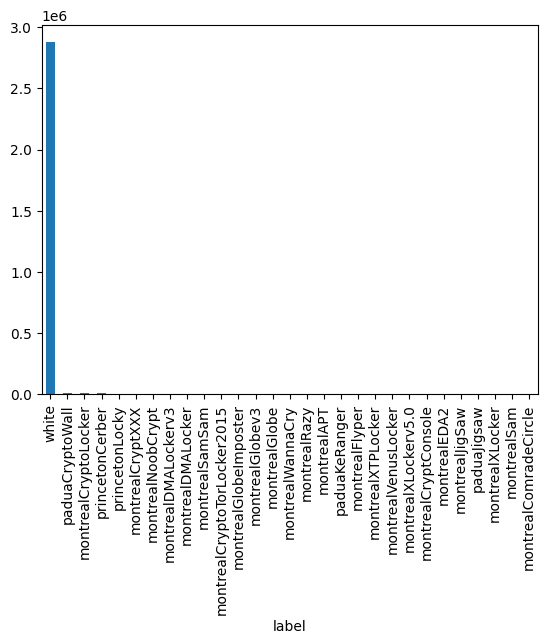

In [12]:
df['label'].value_counts().plot(kind="bar")

In [13]:
df['paddedDay'] = df.day.astype(str).str.pad(width=3, fillchar="0")

In [14]:
df['date'] = df.year.astype(str) + '-' + df['paddedDay']

In [15]:
df

,address,year,day,length,weight,count,looped,neighbors,income,label,paddedDay,date
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017,11,18,0.008333,1,0,2,1.000500e+08,princetonCerber,011,2017-011
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016,132,44,0.000244,1,0,1,1.000000e+08,princetonLocky,132,2016-132
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016,246,0,1.000000,1,0,2,2.000000e+08,princetonCerber,246,2016-246
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016,322,72,0.003906,1,0,2,7.120000e+07,princetonCerber,322,2016-322
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016,238,144,0.072848,456,0,1,2.000000e+08,princetonLocky,238,2016-238
...,...,...,...,...,...,...,...,...,...,...,...,...
2916692,12D3trgho1vJ4mGtWBRPyHdMJK96TRYSry,2018,330,0,0.111111,1,0,1,1.255809e+09,white,330,2018-330
2916693,1P7PputTcVkhXBmXBvSD9MJ3UYPsiou1u2,2018,330,0,1.000000,1,0,1,4.409699e+07,white,330,2018-330
2916694,1KYiKJEfdJtap9QX2v9BXJMpz2SfU4pgZw,2018,330,2,12.000000,6,6,35,2.398267e+09,white,330,2018-330
2916695,15iPUJsRNZQZHmZZVwmQ63srsmughCXV4a,2018,330,0,0.500000,1,0,1,1.780427e+08,white,330,2018-330


In [16]:
df['parsedDate'] = pd.to_datetime(df.date, format="%Y-%j")

In [17]:
df['weekday'] = df['parsedDate'].dt.weekday

In [18]:
df['ransomware'] = np.where(df['label'] != 'white', 1, 0)

In [19]:
df = df.drop('label', axis=1)
df = df.drop('address', axis=1)
df = df.drop('date', axis=1)
df = df.drop('paddedDay', axis=1)
df = df.drop('parsedDate', axis=1)


# Feature Engineering

In [111]:
# 1. Obfuscation Intensity
df['obfuscation_intensity'] = df['looped'] * df['length']

# 2. Merge Density
# If count is 0, return 0, otherwise perform weight / count
df['merge_density'] = np.where(
    df['count'] == 0,
    0,
    df['weight'] / df['count']
)

# 3. Cashing Out Score (Income per Merge)
df['income_per_merge'] = np.where(
    df['count'] == 0,
    0,
    df['income'] / df['count']
)

# 4. Satoshis per Mixing Round
df['income_per_length'] = np.where(
    df['length'] == 0,
    0,
    df['income'] / df['length']
)

# X & y

In [125]:
# New_df is from the random undersample data (fewer instances)
X = df # .drop('ransomware', axis=1).copy()
y = df['ransomware']

# Plots

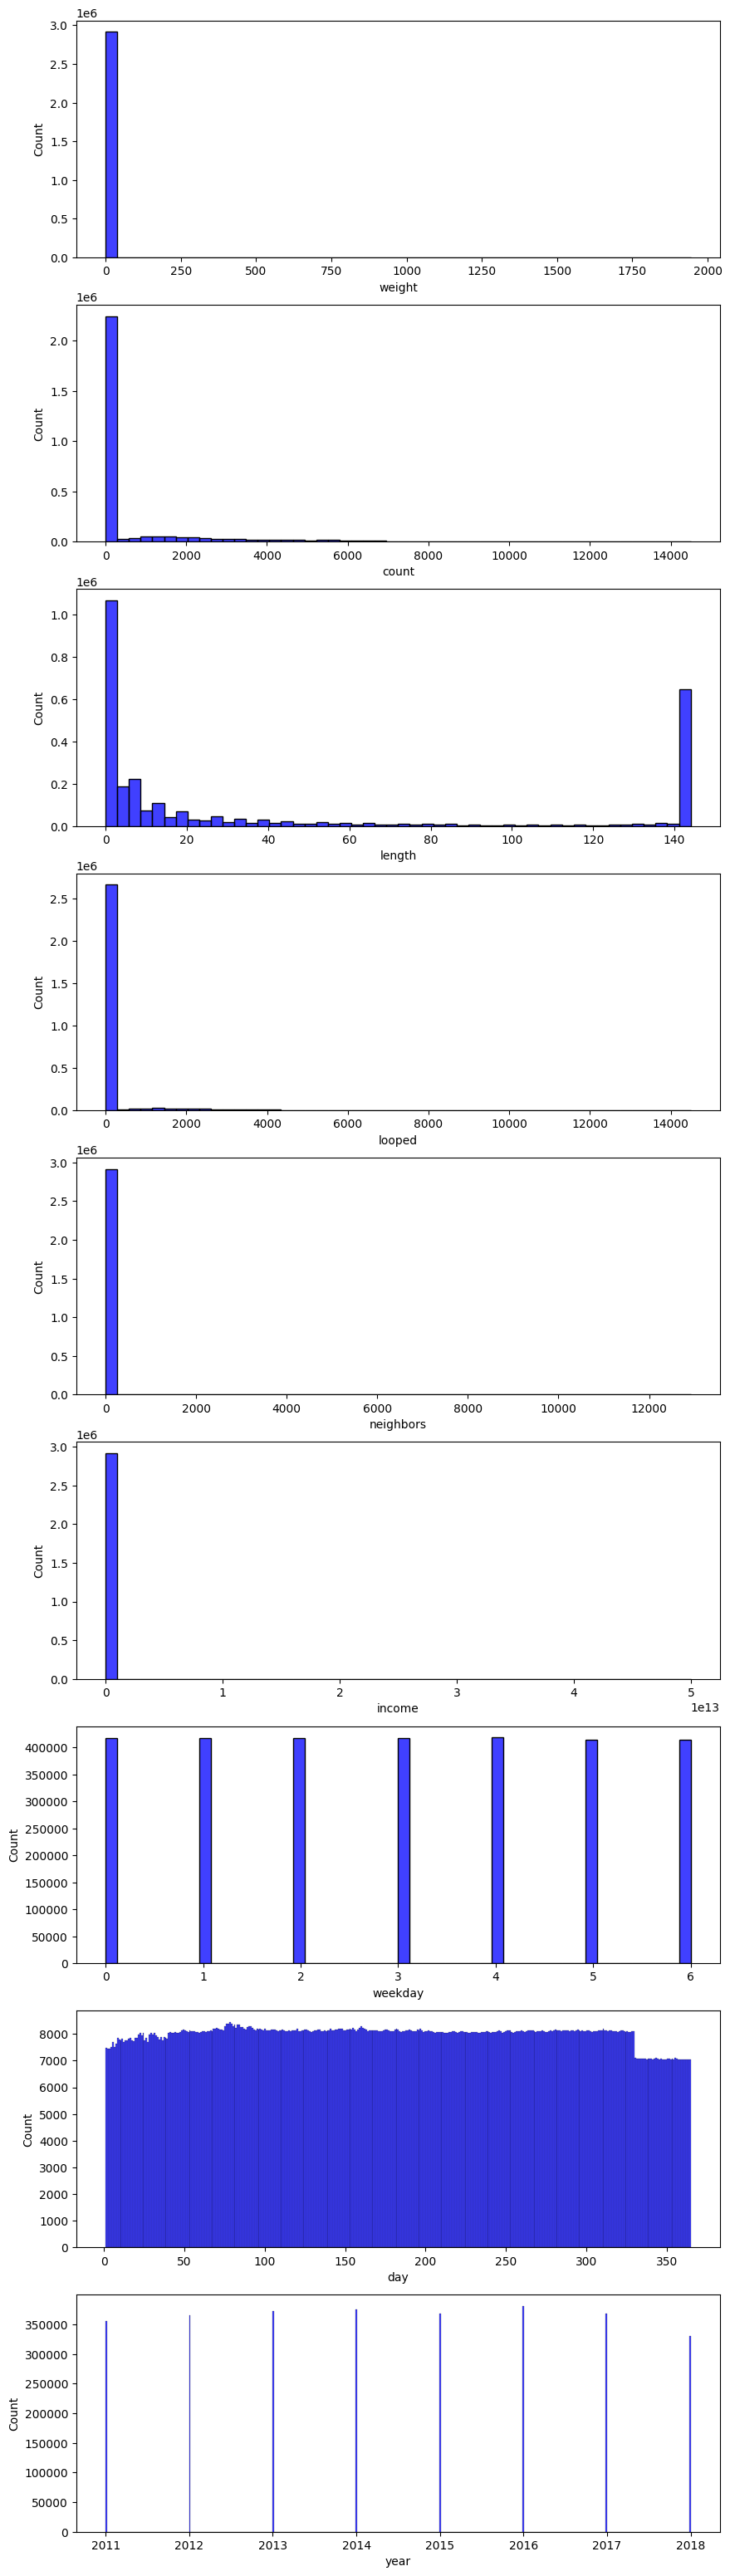

In [20]:
fig, ax = plt.subplots(9, 1, figsize=(10, 16))
plt.subplots_adjust(top=2)

sns.histplot(df['weight'], color='b', bins=50, ax=ax[0]);
sns.histplot(df['count'], color='b', bins=50, ax=ax[1]);
sns.histplot(df['length'], color='b', bins=50, ax=ax[2]);
sns.histplot(df['looped'], color='b', bins=50, ax=ax[3]);
sns.histplot(df['neighbors'], color='b', bins=50, ax=ax[4]);
sns.histplot(df['income'], color='b', bins=50, ax=ax[5]);
sns.histplot(df['weekday'], color='b', bins=50, ax=ax[6]);
sns.histplot(df['day'], color='b', bins=365, ax=ax[7]);
sns.histplot(df['year'], color='b', bins=365, ax=ax[8]);

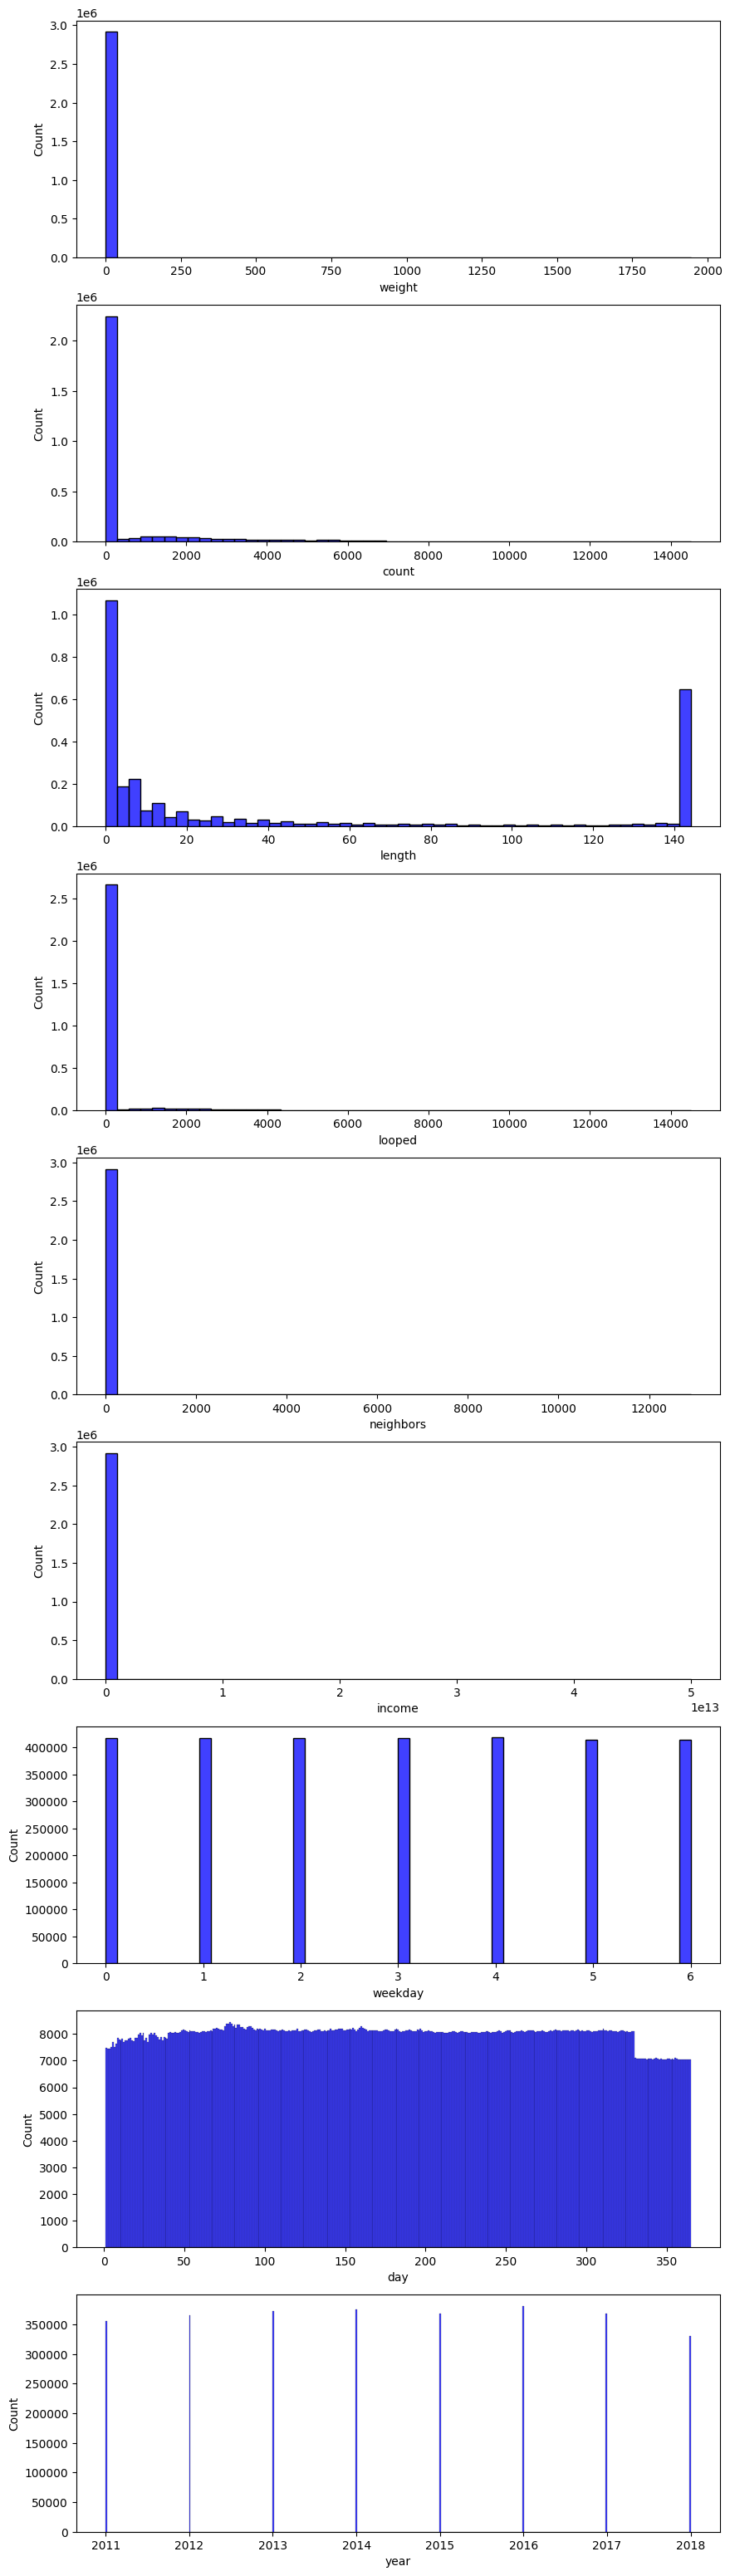

In [20]:
fig, ax = plt.subplots(9, 1, figsize=(10, 16))
plt.subplots_adjust(top=2)

sns.histplot(df['weight'], color='b', bins=50, ax=ax[0]);
sns.histplot(df['count'], color='b', bins=50, ax=ax[1]);
sns.histplot(df['length'], color='b', bins=50, ax=ax[2]);
sns.histplot(df['looped'], color='b', bins=50, ax=ax[3]);
sns.histplot(df['neighbors'], color='b', bins=50, ax=ax[4]);
sns.histplot(df['income'], color='b', bins=50, ax=ax[5]);
sns.histplot(df['weekday'], color='b', bins=50, ax=ax[6]);
sns.histplot(df['day'], color='b', bins=365, ax=ax[7]);
sns.histplot(df['year'], color='b', bins=10, ax=ax[8]);

<Axes: ylabel='weight'>

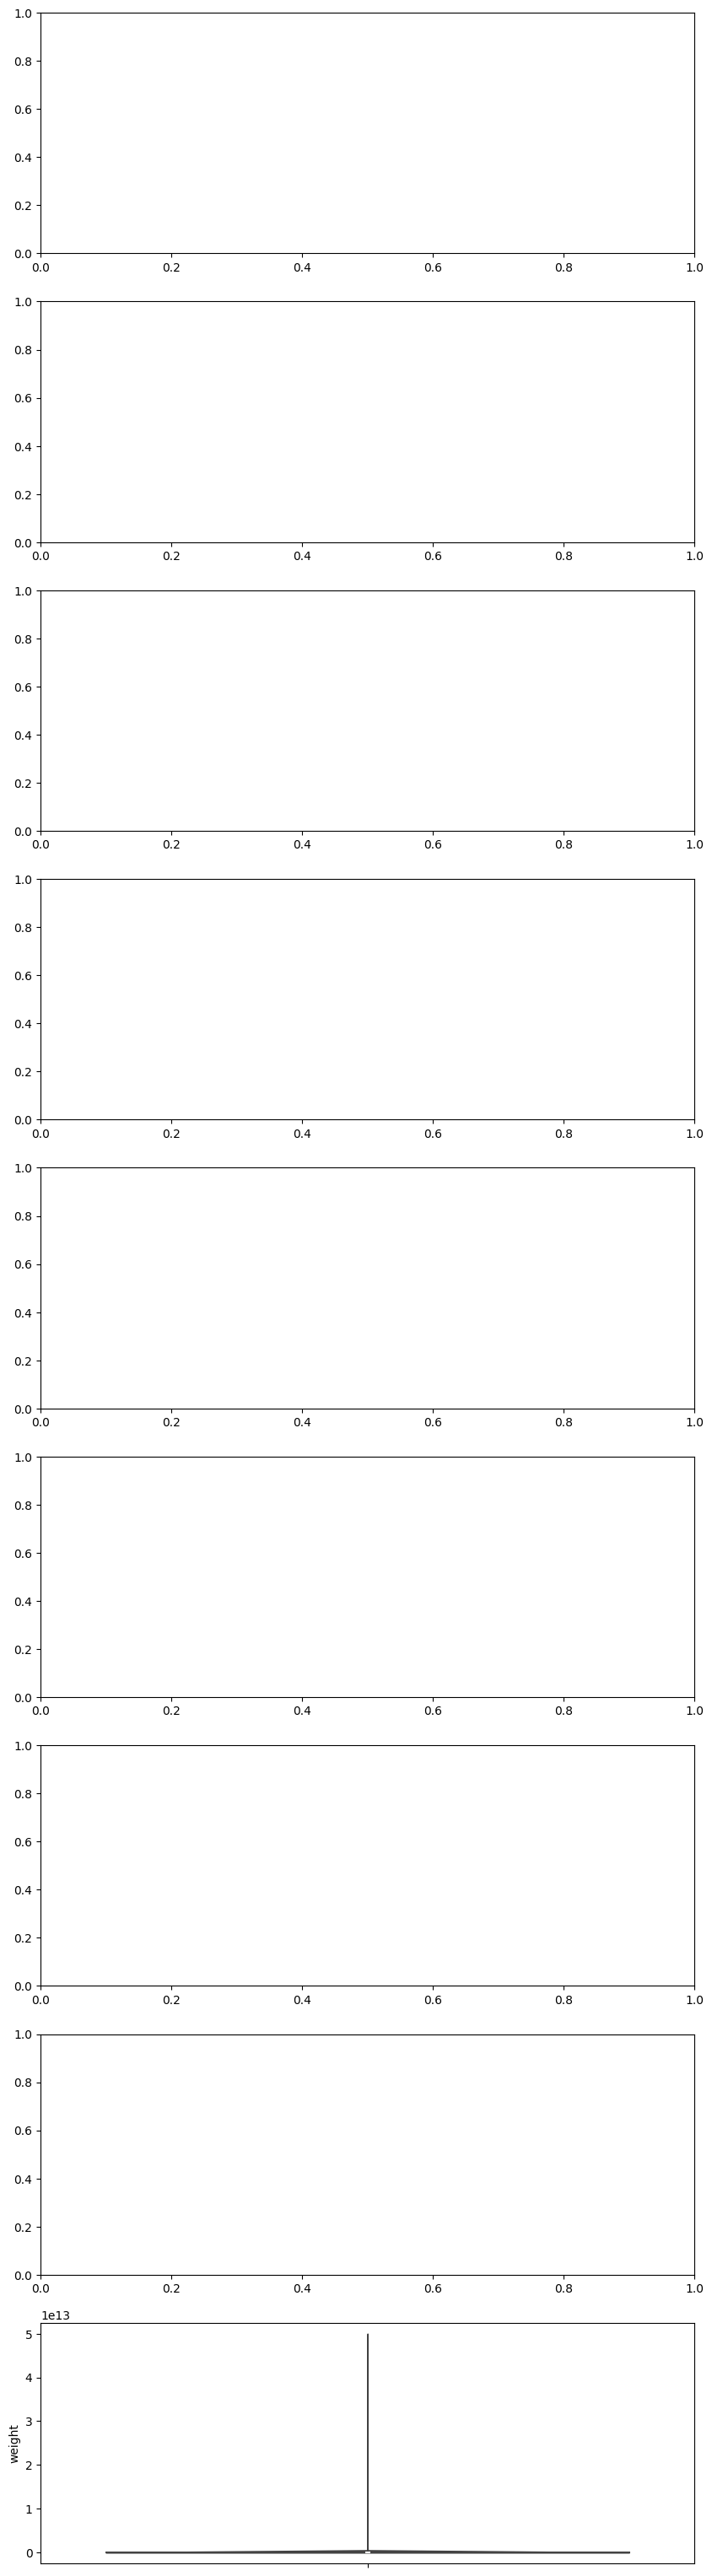

In [102]:
fig, ax = plt.subplots(9, 1, figsize=(10, 16))
plt.subplots_adjust(top=2)

sns.violinplot(df['weight'])
sns.violinplot(df['count'])
sns.violinplot(df['length'])
sns.violinplot(df['looped'])
sns.violinplot(df['neighbors'])
sns.violinplot(df['income'])
sns.violinplot(df['weekday'])
sns.violinplot(df['day'])
sns.violinplot(df['year'])

/var/folders/28/p99ntdsj0s7_b860_0j_389h0000gn/T/ipykernel_9533/3780542448.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


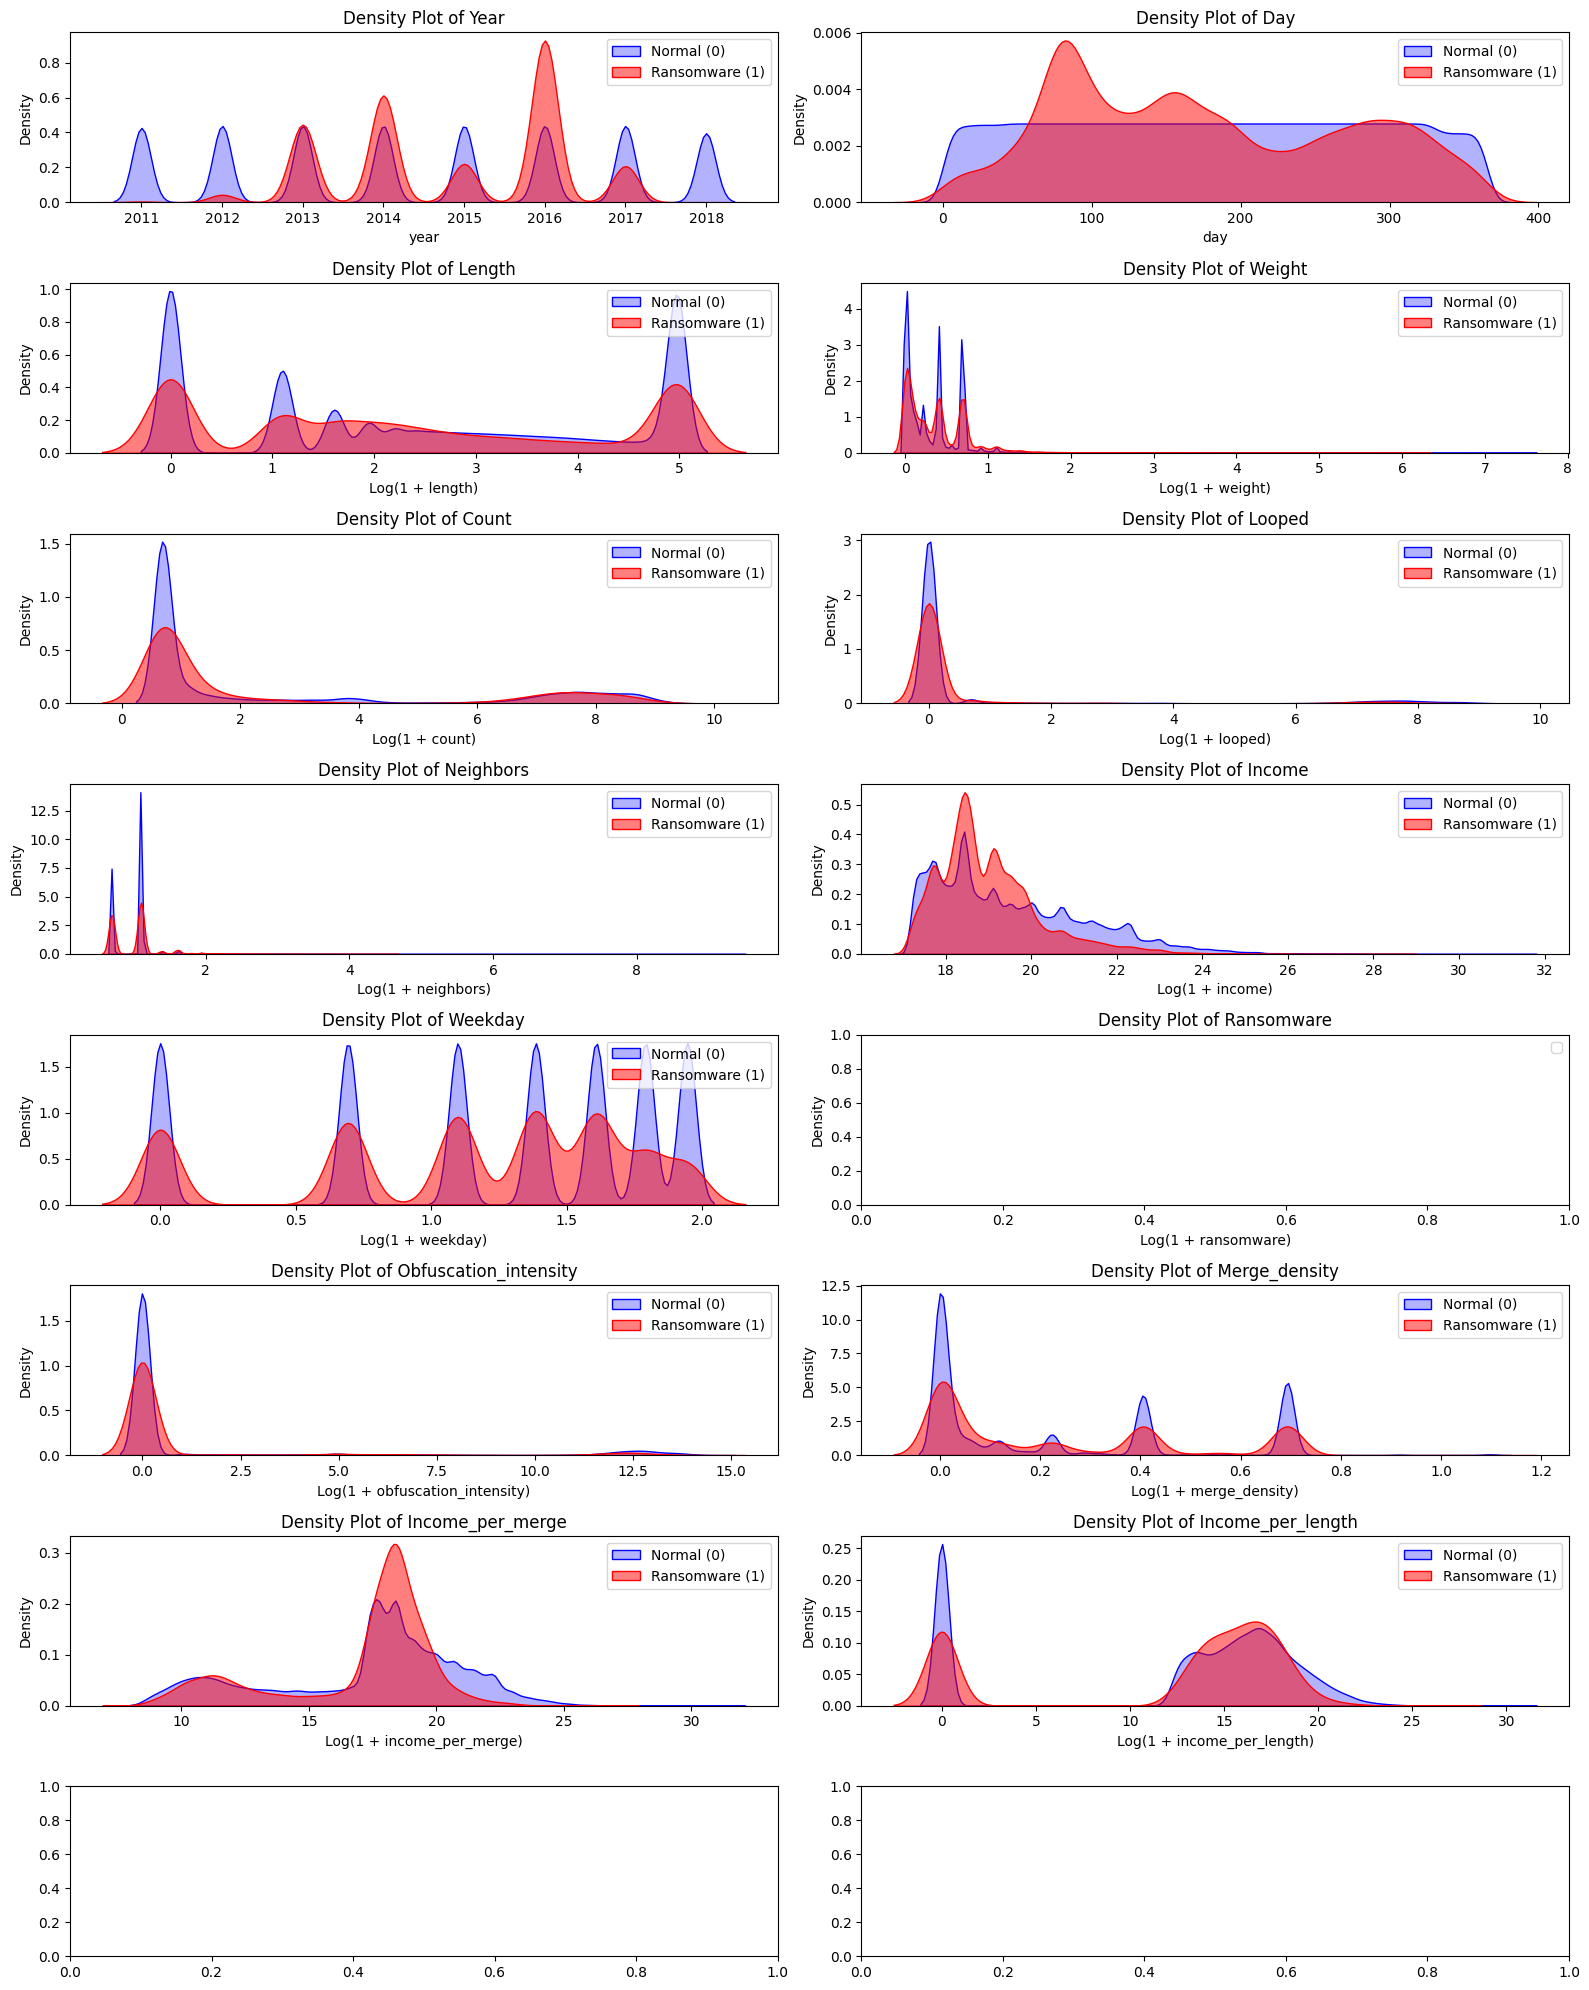

In [123]:
# Define your list of raw features
features = df.columns.tolist()
rows = int(len(features)/2)+1
# Create a 4x2 grid of subplots
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(16, 20))
axes = axes.flatten() # Flatten the 2D array of axes for easy looping

for i, feature in enumerate(features):
    ax = axes[i]

    # Check if the feature needs log-scaling (skip year and day)
    if feature in ['year', 'day']:
        normal_data = df.loc[y == 0, feature]
        ransom_data = df.loc[y == 1, feature]
        ax.set_xlabel(feature)
    else:
        # Apply log(1 + x) for the heavily skewed network features
        normal_data = np.log1p(df.loc[y == 0, feature])
        ransom_data = np.log1p(df.loc[y == 1, feature])
        ax.set_xlabel(f'Log(1 + {feature})')

    # Plot Normal Data (Blue)
    sns.kdeplot(
        normal_data,
        fill=True,
        color="blue",
        label="Normal (0)",
        alpha=0.3,
        ax=ax,
        warn_singular=False # Prevents warnings if a feature has zero variance
    )

    # Plot Ransomware Data (Red)
    sns.kdeplot(
        ransom_data,
        fill=True,
        color="red",
        label="Ransomware (1)",
        alpha=0.5,
        ax=ax,
        warn_singular=False
    )

    ax.set_title(f'Density Plot of {feature.capitalize()}')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

# Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [126]:
# 1. Separate the dataset into White (0) and Ransomware (1)
white_X = X[y == 0].copy()
white_y = y[y == 0].copy()

ransomware_X = X[y == 1].copy()
ransomware_y = y[y == 1].copy()

print(f"Original White addresses: {len(white_X)}")

# 2. Define the features that have massive extreme outliers
# We exclude cyclic features like 'year' and 'day'
features_to_trim = ['income', 'weight', 'count', 'neighbors', 'length', 'looped']

# 3. Set your strict percentile threshold (e.g., 99.9th percentile)
# This means we only drop the top 0.1% most extreme normal transactions
percentile_threshold = 0.999

# 4. Apply the trimming iteratively
for feature in features_to_trim:
    # Calculate the exact cutoff number for this specific feature
    cutoff_value = white_X[feature].quantile(percentile_threshold)

    # Create a mask to keep only the rows below the cutoff
    # We apply this mask to both X and y simultaneously to keep them aligned
    mask = white_X[feature] <= cutoff_value
    white_X = white_X[mask]
    white_y = white_y[mask]

print(f"Trimmed White addresses: {len(white_X)}")
print(f"Total outliers removed: {len(y[y == 0]) - len(white_X)}")

# 5. Recombine the trimmed white data with the untouched ransomware data
X_trimmed = pd.concat([white_X, ransomware_X])
y_trimmed = pd.concat([white_y, ransomware_y])

# 6. Shuffle the dataset so the classes aren't stacked on top of each other
# (Optional, but good practice before feeding into a model or train_test_split)
shuffled_indices = np.random.permutation(len(X_trimmed))
X_trimmed = X_trimmed.iloc[shuffled_indices].reset_index(drop=True)
y_trimmed = y_trimmed.iloc[shuffled_indices].reset_index(drop=True)

print("\nDataset successfully recombined and shuffled!")
print(f"Final dataset size: {len(X_trimmed)} rows.")

Original White addresses: 2875284
Trimmed White addresses: 2861019
Total outliers removed: 14265

Dataset successfully recombined and shuffled!
Final dataset size: 2902432 rows.


/var/folders/28/p99ntdsj0s7_b860_0j_389h0000gn/T/ipykernel_9533/1592437026.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


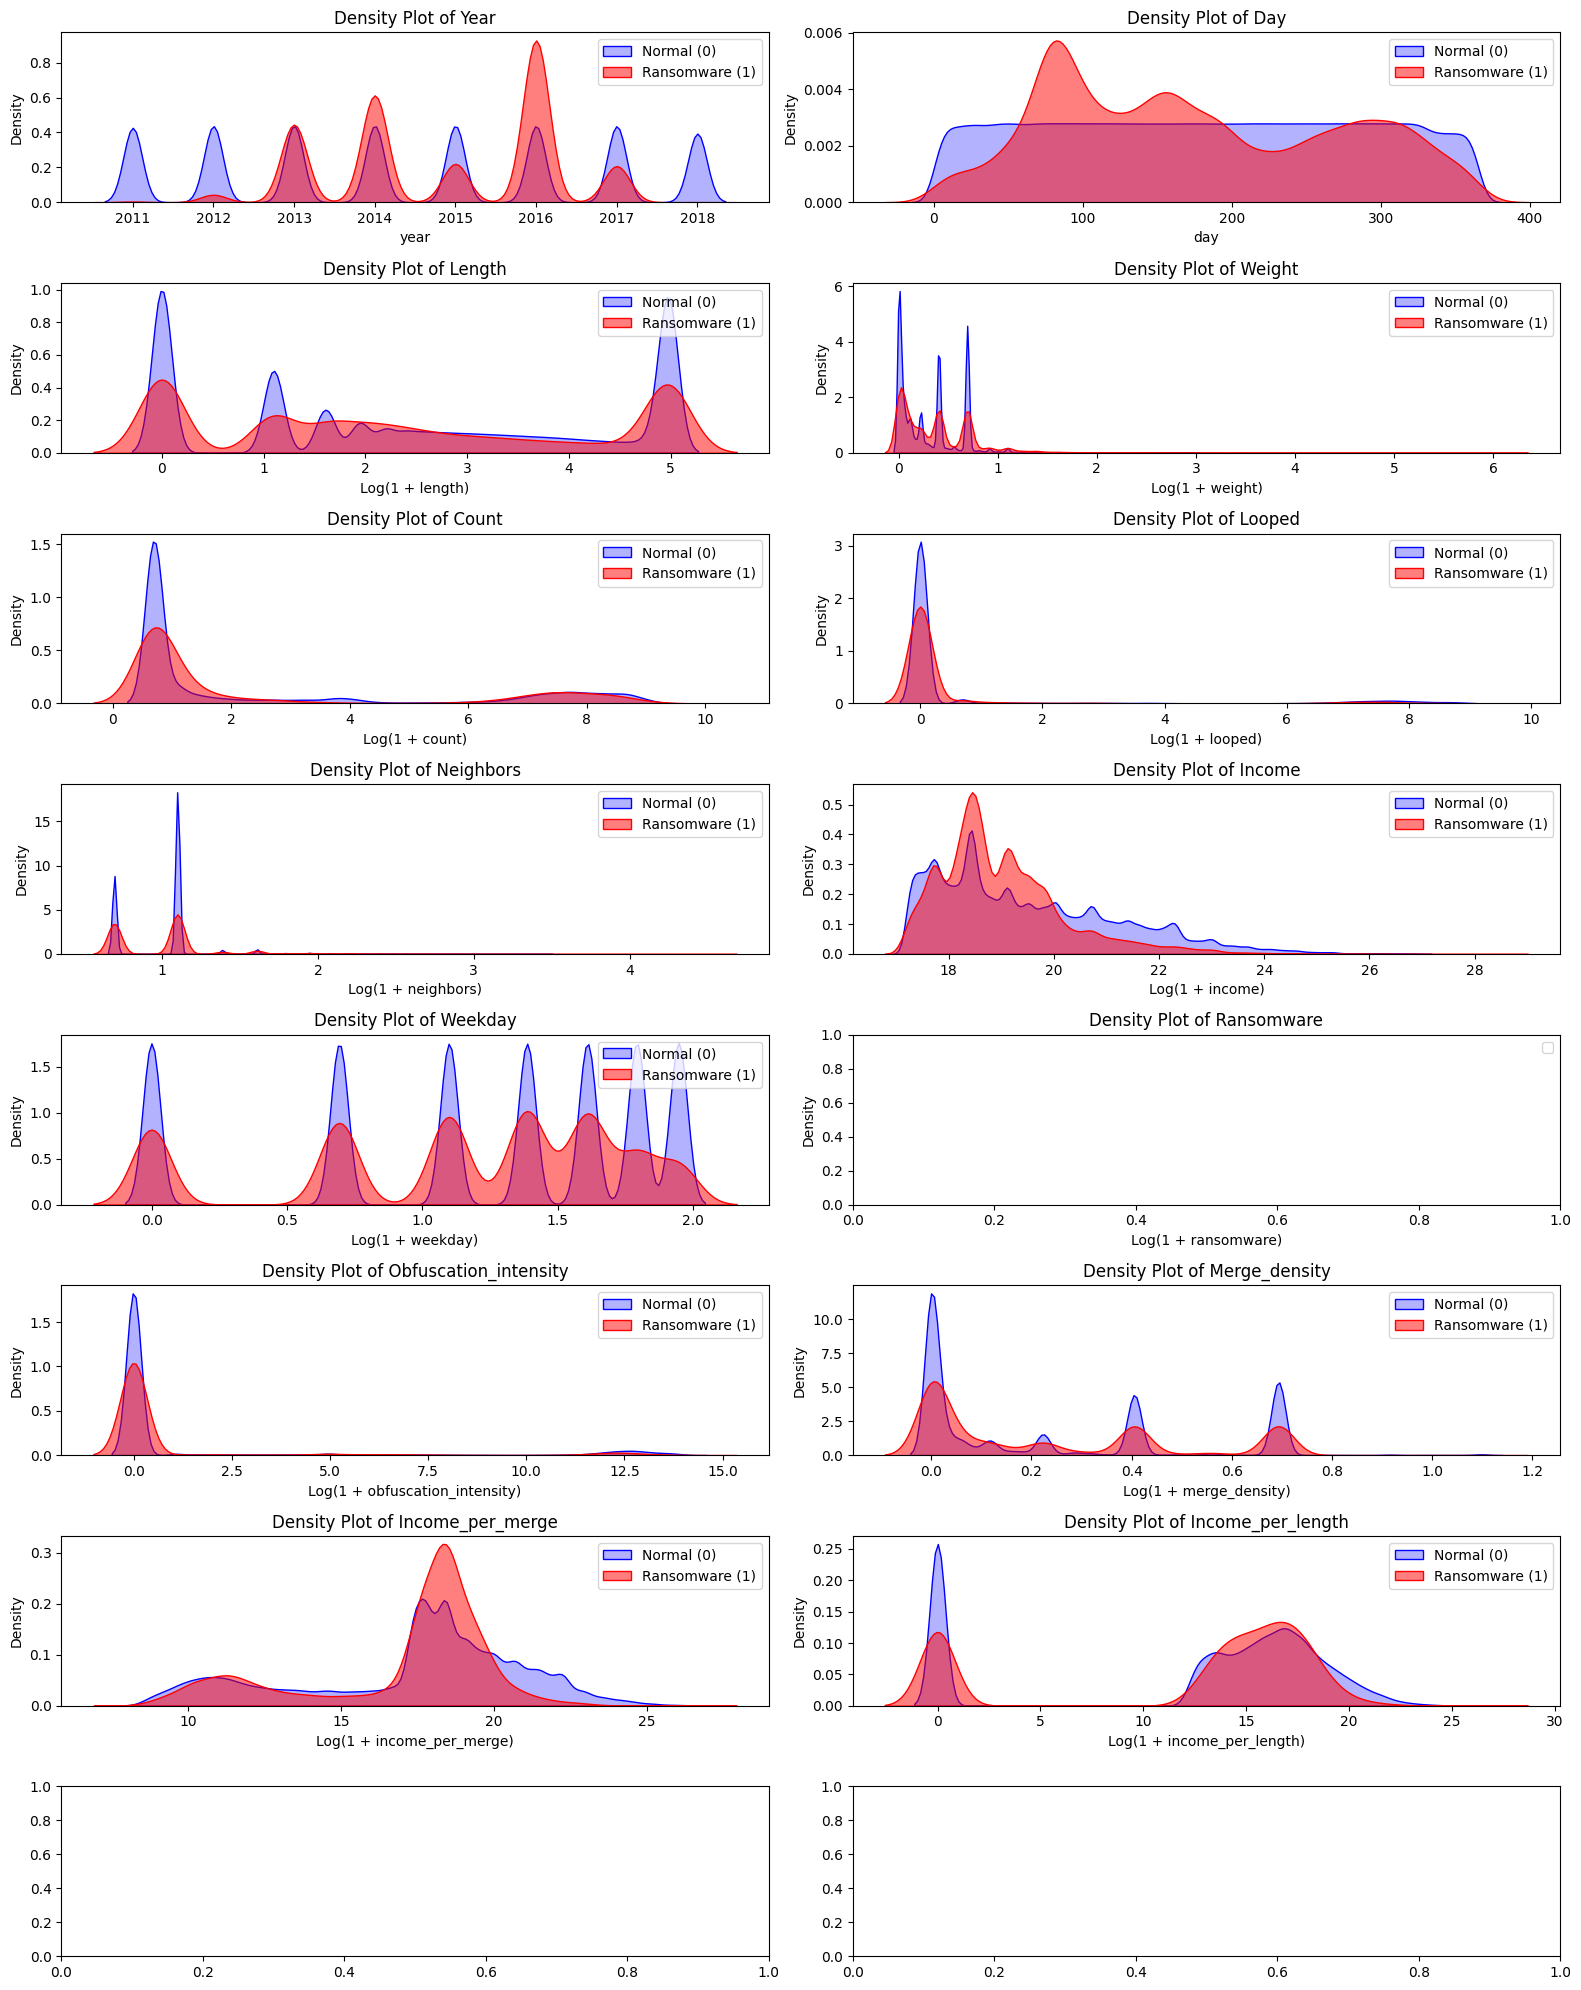

In [127]:
# Define your list of raw features
features = df.columns.tolist()
rows = int(len(features) / 2) + 1
# Create a 4x2 grid of subplots
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(16, 20))
axes = axes.flatten()  # Flatten the 2D array of axes for easy looping

for i, feature in enumerate(features):
    ax = axes[i]

    # Check if the feature needs log-scaling (skip year and day)
    if feature in ['year', 'day']:
        normal_data = X_trimmed.loc[y_trimmed == 0, feature]
        ransom_data = X_trimmed.loc[y_trimmed == 1, feature]
        ax.set_xlabel(feature)
    else:
        # Apply log(1 + x) for the heavily skewed network features
        normal_data = np.log1p(X_trimmed.loc[y_trimmed == 0, feature])
        ransom_data = np.log1p(X_trimmed.loc[y_trimmed == 1, feature])
        ax.set_xlabel(f'Log(1 + {feature})')

    # Plot Normal Data (Blue)
    sns.kdeplot(
        normal_data,
        fill=True,
        color="blue",
        label="Normal (0)",
        alpha=0.3,
        ax=ax,
        warn_singular=False  # Prevents warnings if a feature has zero variance
    )

    # Plot Ransomware Data (Red)
    sns.kdeplot(
        ransom_data,
        fill=True,
        color="red",
        label="Ransomware (1)",
        alpha=0.5,
        ax=ax,
        warn_singular=False
    )

    ax.set_title(f'Density Plot of {feature.capitalize()}')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

# Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [21]:
df.columns

Index(['year', 'day', 'length', 'weight', 'count', 'looped', 'neighbors',
       'income', 'weekday', 'ransomware'],
      dtype='str')

In [22]:
feature_mapping = {
    "weight": "weight",
    "count": "count",
}

features = ['weight',
            'count'
            # 'length',
            # 'looped',
            # 'neighbors',
            # 'income',
            # 'weekday',
            # 'day',
            # 'year'
            ]

In [23]:
features_idx = [df.columns.to_list().index(feature) for feature in features]

In [26]:
distributions = [
    ("Unscaled data", X),
    ("Data after standard scaling", StandardScaler().fit_transform(X)),
    ("Data after min-max scaling", MinMaxScaler().fit_transform(X)),
    ("Data after max-abs scaling", MaxAbsScaler().fit_transform(X)),
    (
        "Data after robust scaling",
        RobustScaler(quantile_range=(25, 75)).fit_transform(X),
    ),
    (
        "Data after power transformation (Yeo-Johnson)",
        PowerTransformer(method="yeo-johnson").fit_transform(X),
    ),
    (
        "Data after power transformation (Box-Cox)",
        PowerTransformer(method="box-cox").fit_transform(X),
    ),
    (
        "Data after quantile transformation (uniform pdf)",
        QuantileTransformer(
            output_distribution="uniform", random_state=42
        ).fit_transform(X),
    ),
    # (
    #     "Data after quantile transformation (gaussian pdf)",
    #     QuantileTransformer(
    #         output_distribution="normal", random_state=42
    #     ).fit_transform(X),
    # ),
    ("Data after sample-wise L2 normalizing", Normalizer().fit_transform(X)),
]


In [27]:
X

array([[8.33333333e-03, 1.00000000e+00],
       [2.44140625e-04, 1.00000000e+00],
       [1.00000000e+00, 1.00000000e+00],
       ...,
       [1.56250000e-02, 1.00000000e+00],
       [1.00000000e+00, 1.00000000e+00],
       [2.20630787e-03, 2.90000000e+01]], shape=(233576, 2))

In [28]:
# scale the output between 0 and 1 for the colorbar
y = minmax_scale(df[:233576][features[1]].to_numpy())

# plasma does not exist in matplotlib < 1.5
cmap = getattr(cm, "plasma_r", cm.hot_r)

In [30]:
def create_axes(title, figsize=(16, 6)):
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    # define the axis for the first plot
    left, width = 0.1, 0.22
    bottom, height = 0.1, 0.7
    bottom_h = height + 0.15
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter = plt.axes(rect_scatter)
    ax_histx = plt.axes(rect_histx)
    ax_histy = plt.axes(rect_histy)

    # define the axis for the zoomed-in plot
    left = width + left + 0.2
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter_zoom = plt.axes(rect_scatter)
    ax_histx_zoom = plt.axes(rect_histx)
    ax_histy_zoom = plt.axes(rect_histy)

    # define the axis for the colorbar
    left, width = width + left + 0.13, 0.01

    rect_colorbar = [left, bottom, width, height]
    ax_colorbar = plt.axes(rect_colorbar)

    return (
        (ax_scatter, ax_histy, ax_histx),
        (ax_scatter_zoom, ax_histy_zoom, ax_histx_zoom),
        ax_colorbar,
    )


def plot_distribution(axes, X, y, hist_nbins=50, title="", x0_label="", x1_label=""):
    ax, hist_X1, hist_X0 = axes

    ax.set_title(title)
    ax.set_xlabel(x0_label)
    ax.set_ylabel(x1_label)

    # The scatter plot
    colors = cmap(y)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5, marker="o", s=5, lw=0, c=colors)

    # Removing the top and the right spine for aesthetics
    # make nice axis layout
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))

    # Histogram for axis X1 (feature 5)
    hist_X1.set_ylim(ax.get_ylim())
    hist_X1.hist(
        X[:, 1], bins=hist_nbins, orientation="horizontal", color="grey", ec="grey"
    )
    hist_X1.axis("off")

    # Histogram for axis X0 (feature 0)
    hist_X0.set_xlim(ax.get_xlim())
    hist_X0.hist(
        X[:, 0], bins=hist_nbins, orientation="vertical", color="grey", ec="grey"
    )
    hist_X0.axis("off")

In [31]:
def make_plot(item_idx):
    title, X = distributions[item_idx]
    ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes(title)
    axarr = (ax_zoom_out, ax_zoom_in)
    plot_distribution(
        axarr[0],
        X,
        y,
        hist_nbins=200,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Full data",
    )

    # zoom-in
    zoom_in_percentile_range = (0, 99)
    cutoffs_X0 = np.percentile(X[:, 0], zoom_in_percentile_range)
    cutoffs_X1 = np.percentile(X[:, 1], zoom_in_percentile_range)

    non_outliers_mask = np.all(X > [cutoffs_X0[0], cutoffs_X1[0]], axis=1) & np.all(
        X < [cutoffs_X0[1], cutoffs_X1[1]], axis=1
    )
    plot_distribution(
        axarr[1],
        X[non_outliers_mask],
        y[non_outliers_mask],
        hist_nbins=50,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Zoom-in",
    )

    norm = mpl.colors.Normalize(df[0:233576][features[0]].to_numpy().min(), df[0:233576][features[0]].to_numpy().max())
    mpl.colorbar.ColorbarBase(
        ax_colorbar,
        cmap=cmap,
        norm=norm,
        orientation="vertical",
        label="Color mapping for values of y",
    )


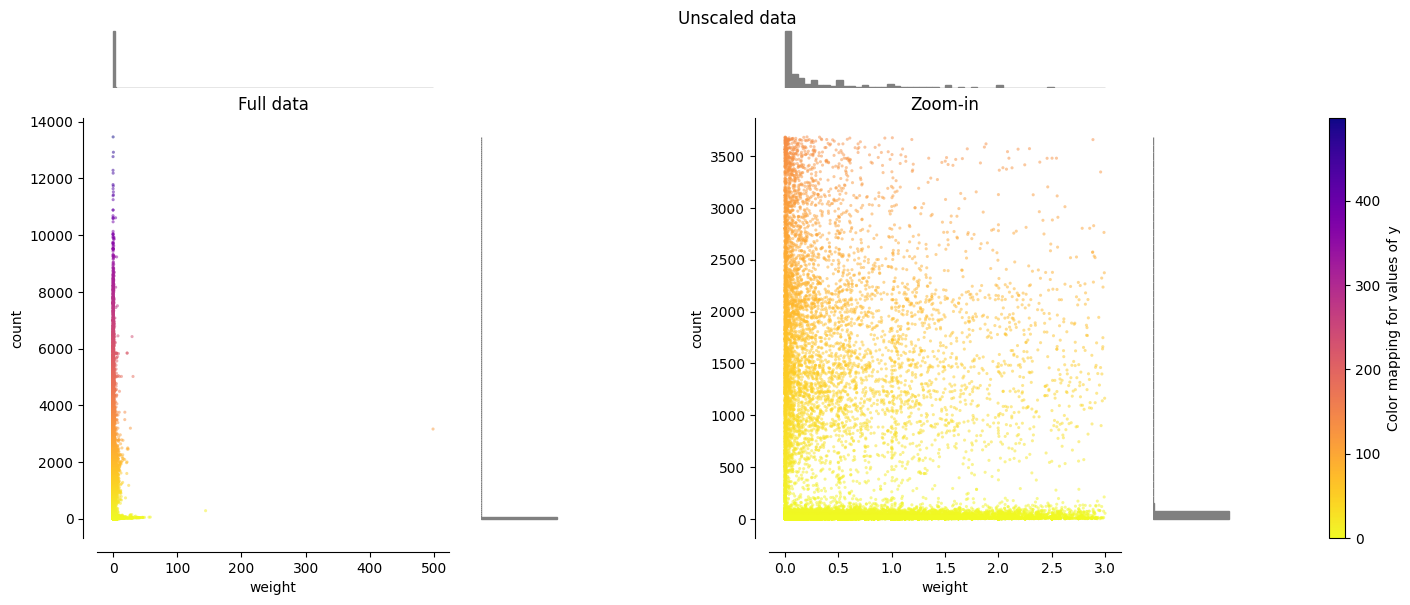

In [32]:
make_plot(0)

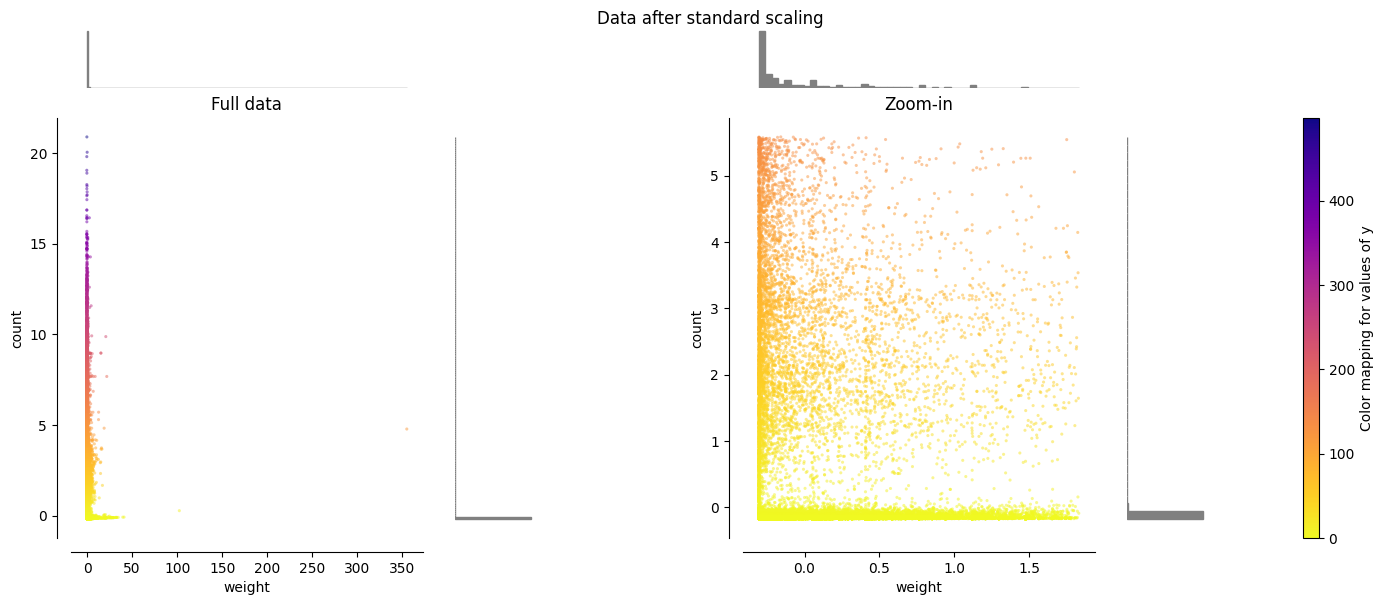

In [33]:
make_plot(1)

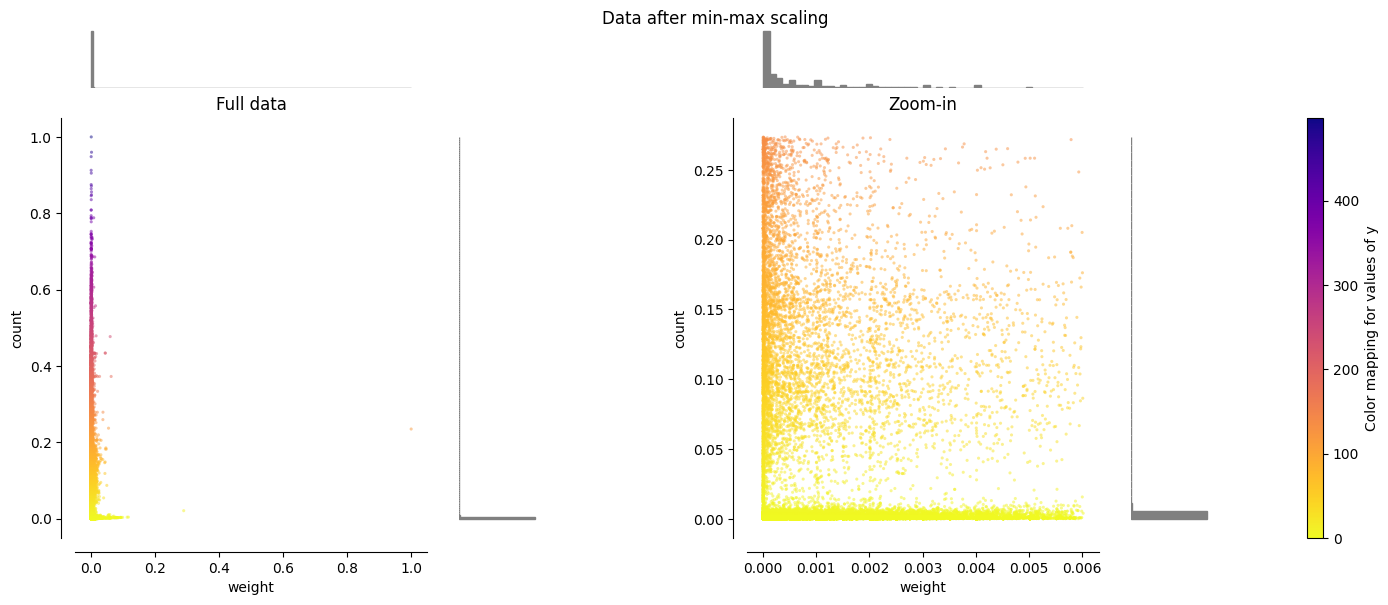

In [34]:
make_plot(2)

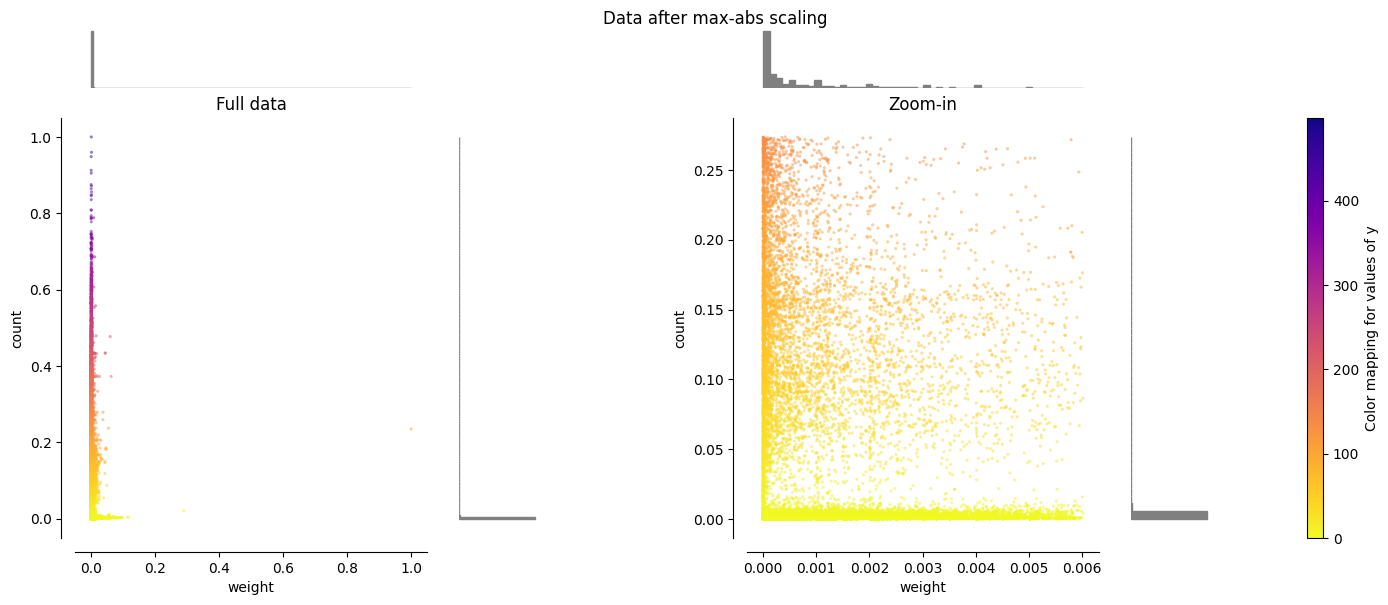

In [35]:
make_plot(3)

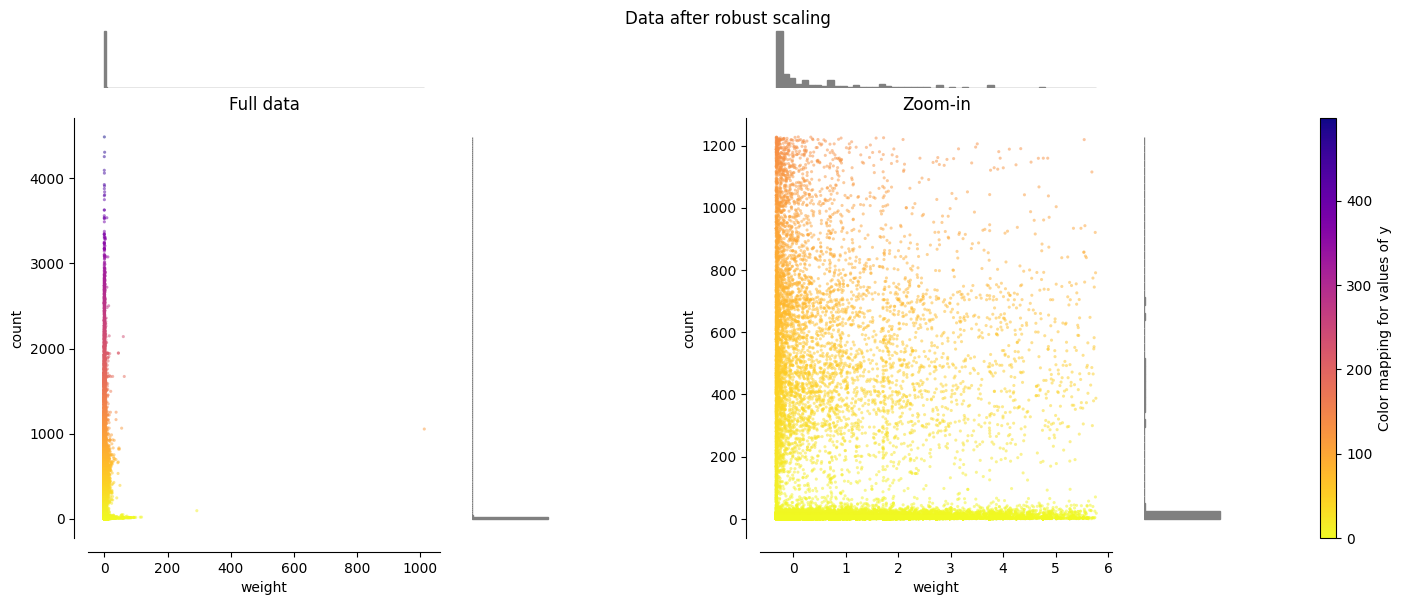

In [36]:
make_plot(4)

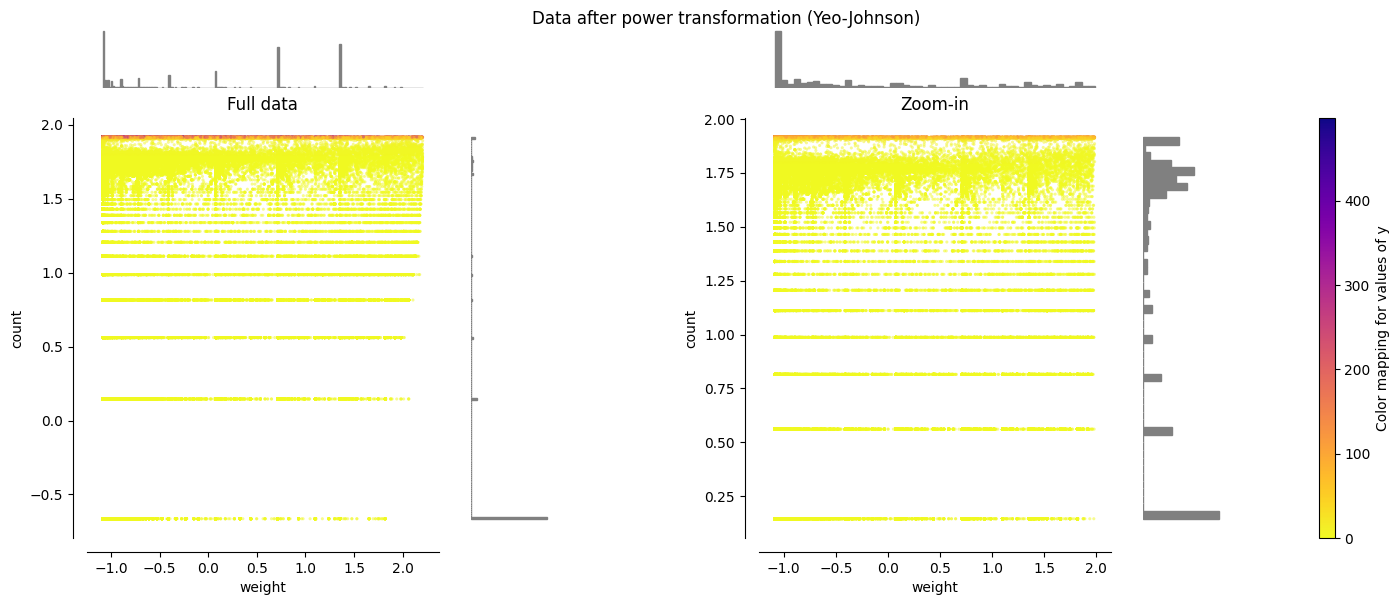

In [37]:
make_plot(5)

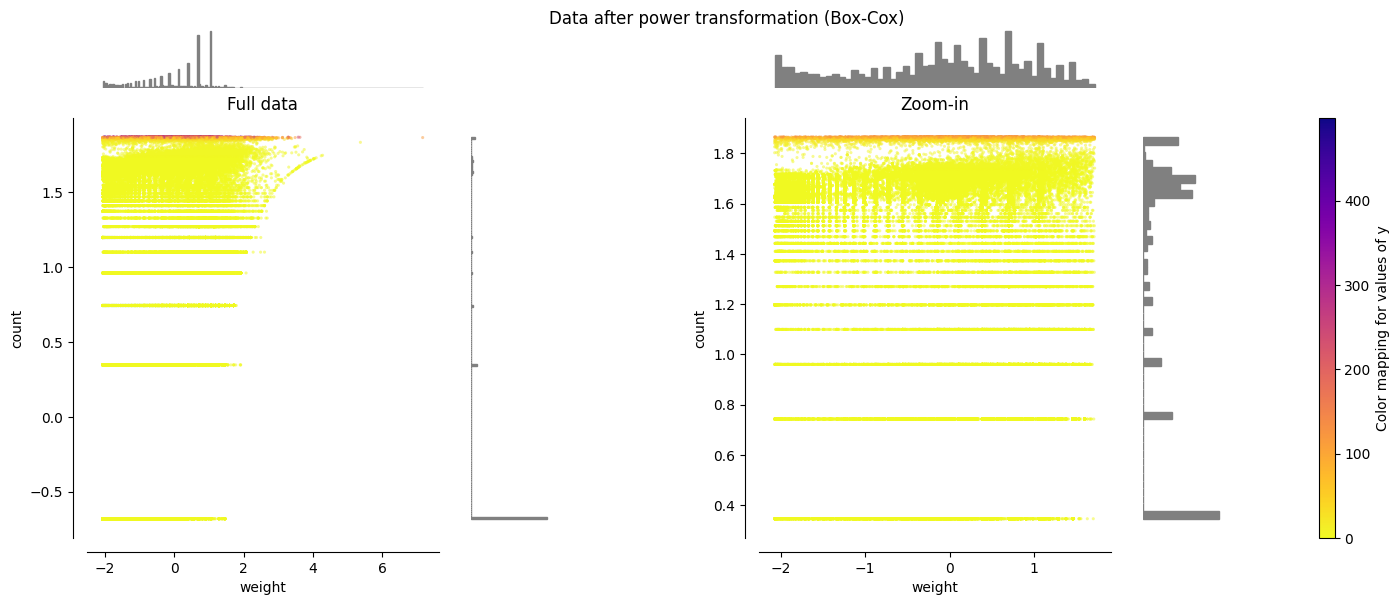

In [38]:
make_plot(6)

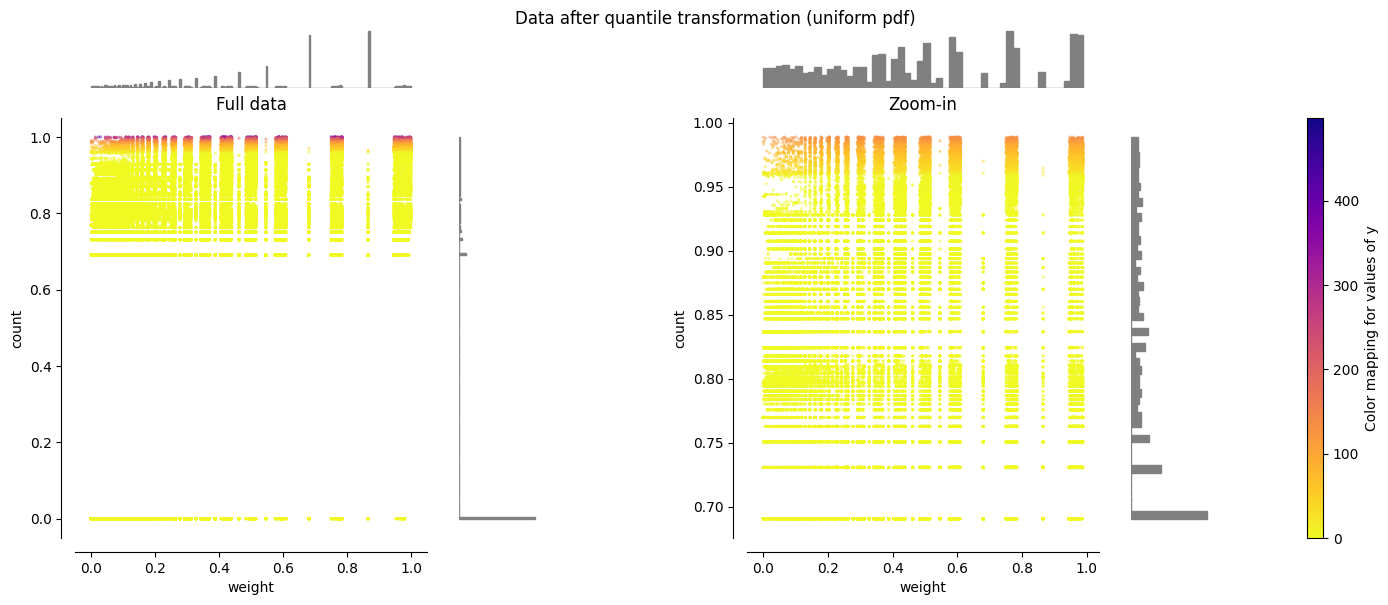

In [39]:
make_plot(7)

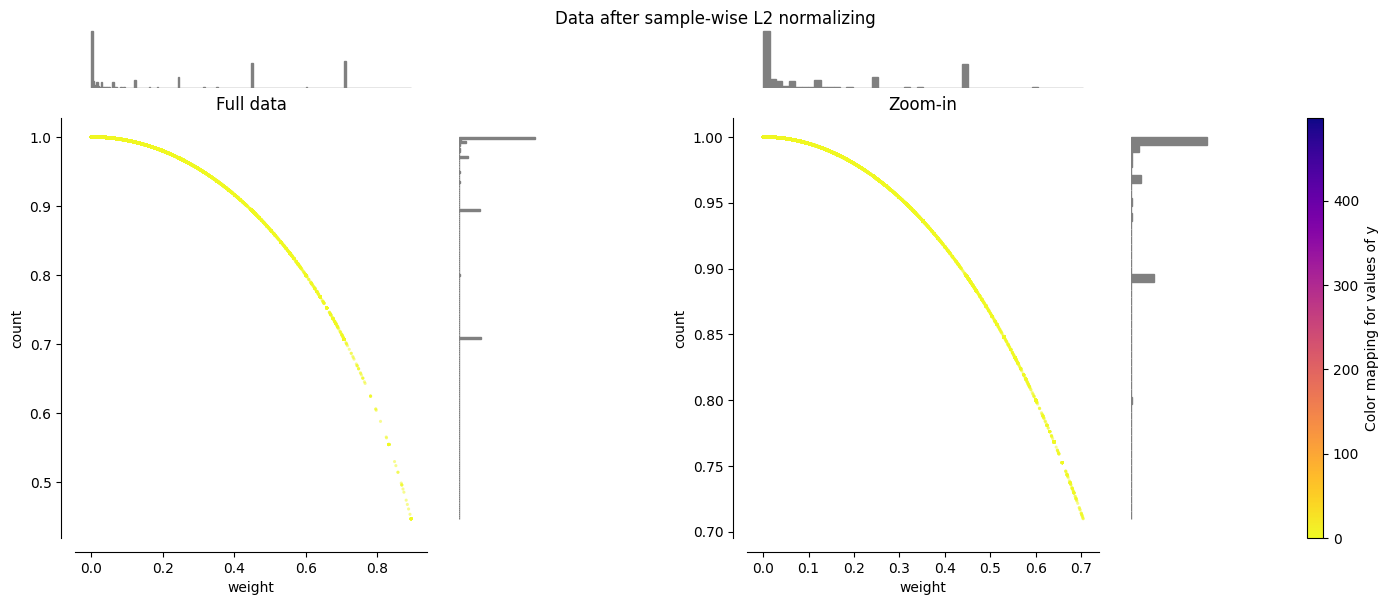

In [40]:
make_plot(8)

# Scaling Features

In [ ]:
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

Logarithmic Transformation

“When a feature’s distribution has a heavy tail (i.e., when values far from the mean are not exponentially rare), both min-max scaling and standardization will squash most values into a small range. Machine learning models generally don’t like this at all, as you will see in Chapter 4. So before you scale the feature, you should first transform it to shrink the heavy tail, and if possible to make the distribution roughly symmetrical. For example, a common way to do this for positive features with a heavy tail to the right is to replace the feature with its square root (or raise the feature to a power between 0 and 1). If the feature has a really long and heavy tail, such as a power law distribution, then replacing the feature with its logarithm may help”

Excerpt From
Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow
Aurélien Géron
This material may be protected by copyright.

In [ ]:
df

,year,day,length,weight,count,looped,neighbors,income,weekday,ransomware
0,2017,11,18,0.008333,1,0,2,1.000500e+08,2,1
1,2016,132,44,0.000244,1,0,1,1.000000e+08,2,1
2,2016,246,0,1.000000,1,0,2,2.000000e+08,4,1
3,2016,322,72,0.003906,1,0,2,7.120000e+07,3,1
4,2016,238,144,0.072848,456,0,1,2.000000e+08,3,1
...,...,...,...,...,...,...,...,...,...,...
2916692,2018,330,0,0.111111,1,0,1,1.255809e+09,0,0
2916693,2018,330,0,1.000000,1,0,1,4.409699e+07,0,0
2916694,2018,330,2,12.000000,6,6,35,2.398267e+09,0,0
2916695,2018,330,0,0.500000,1,0,1,1.780427e+08,0,0


In [ ]:
df.describe()

,year,day,length,weight,count,looped,neighbors,income,weekday,ransomware
count,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06
mean,2.014475e+03,1.814572e+02,4.500859e+01,5.455192e-01,7.216446e+02,2.385067e+02,2.206516e+00,4.464889e+09,2.996592e+00,1.419860e-02
std,2.257398e+00,1.040118e+02,5.898236e+01,3.674255e+00,1.689676e+03,9.663217e+02,1.791877e+01,1.626860e+11,1.998051e+00,1.183089e-01
min,2.011000e+03,1.000000e+00,0.000000e+00,3.606469e-94,1.000000e+00,0.000000e+00,1.000000e+00,3.000000e+07,0.000000e+00,0.000000e+00
25%,2.013000e+03,9.200000e+01,2.000000e+00,2.148438e-02,1.000000e+00,0.000000e+00,1.000000e+00,7.428559e+07,1.000000e+00,0.000000e+00
50%,2.014000e+03,1.810000e+02,8.000000e+00,2.500000e-01,1.000000e+00,0.000000e+00,2.000000e+00,1.999985e+08,3.000000e+00,0.000000e+00
75%,2.016000e+03,2.710000e+02,1.080000e+02,8.819482e-01,5.600000e+01,0.000000e+00,2.000000e+00,9.940000e+08,5.000000e+00,0.000000e+00
max,2.018000e+03,3.650000e+02,1.440000e+02,1.943749e+03,1.449700e+04,1.449600e+04,1.292000e+04,4.996440e+13,6.000000e+00,1.000000e+00


log1p():

Computes log(x + 1).

This function was be implemented to produce more precise result for x near zero.

Special cases:

    log1p(NaN) is NaN

    log1p(x) is NaN where x < -1.0

    log1p(-1.0) is -Inf

    log1p(+Inf) is +Inf

In [ ]:
skewed_features = ['weight', 'count', 'neighbors', 'income']

for feature in skewed_features:
    df[f'log_{feature}'] = np.log1p(df[feature])

features_to_scale = ['length', 'log_weight', 'log_count', 'log_neighbors', 'log_income']

scaler = PowerTransformer(method="yeo-johnson")

scaled_data = scaler.fit_transform(df[features_to_scale])

df_scaled = pd.DataFrame(
    scaled_data,
    columns=['scaled_length', 'scaled_weight', 'scaled_count', 'scaled_neighbors', 'scaled_income']
)

In [ ]:
df_scaled.describe()

,scaled_length,scaled_weight,scaled_count,scaled_neighbors,scaled_income
count,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06
mean,-4.339304e-16,-4.489771e-16,-2.106234e-16,-3.544707e-15,-1.024152e-09
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.309941e+00,-1.226094e+00,-7.951091e-01,-1.379599e+00,-1.714258e+00
25%,-6.980496e-01,-1.086809e+00,-7.951091e-01,-1.379599e+00,-8.062002e-01
50%,-1.061509e-01,-6.281021e-02,-7.951091e-01,4.867206e-01,-4.184618e-02
75%,1.166806e+00,1.078823e+00,1.205967e+00,4.867206e-01,8.457548e-01
max,1.306436e+00,2.933437e+00,1.566722e+00,4.875025e+00,2.731564e+00


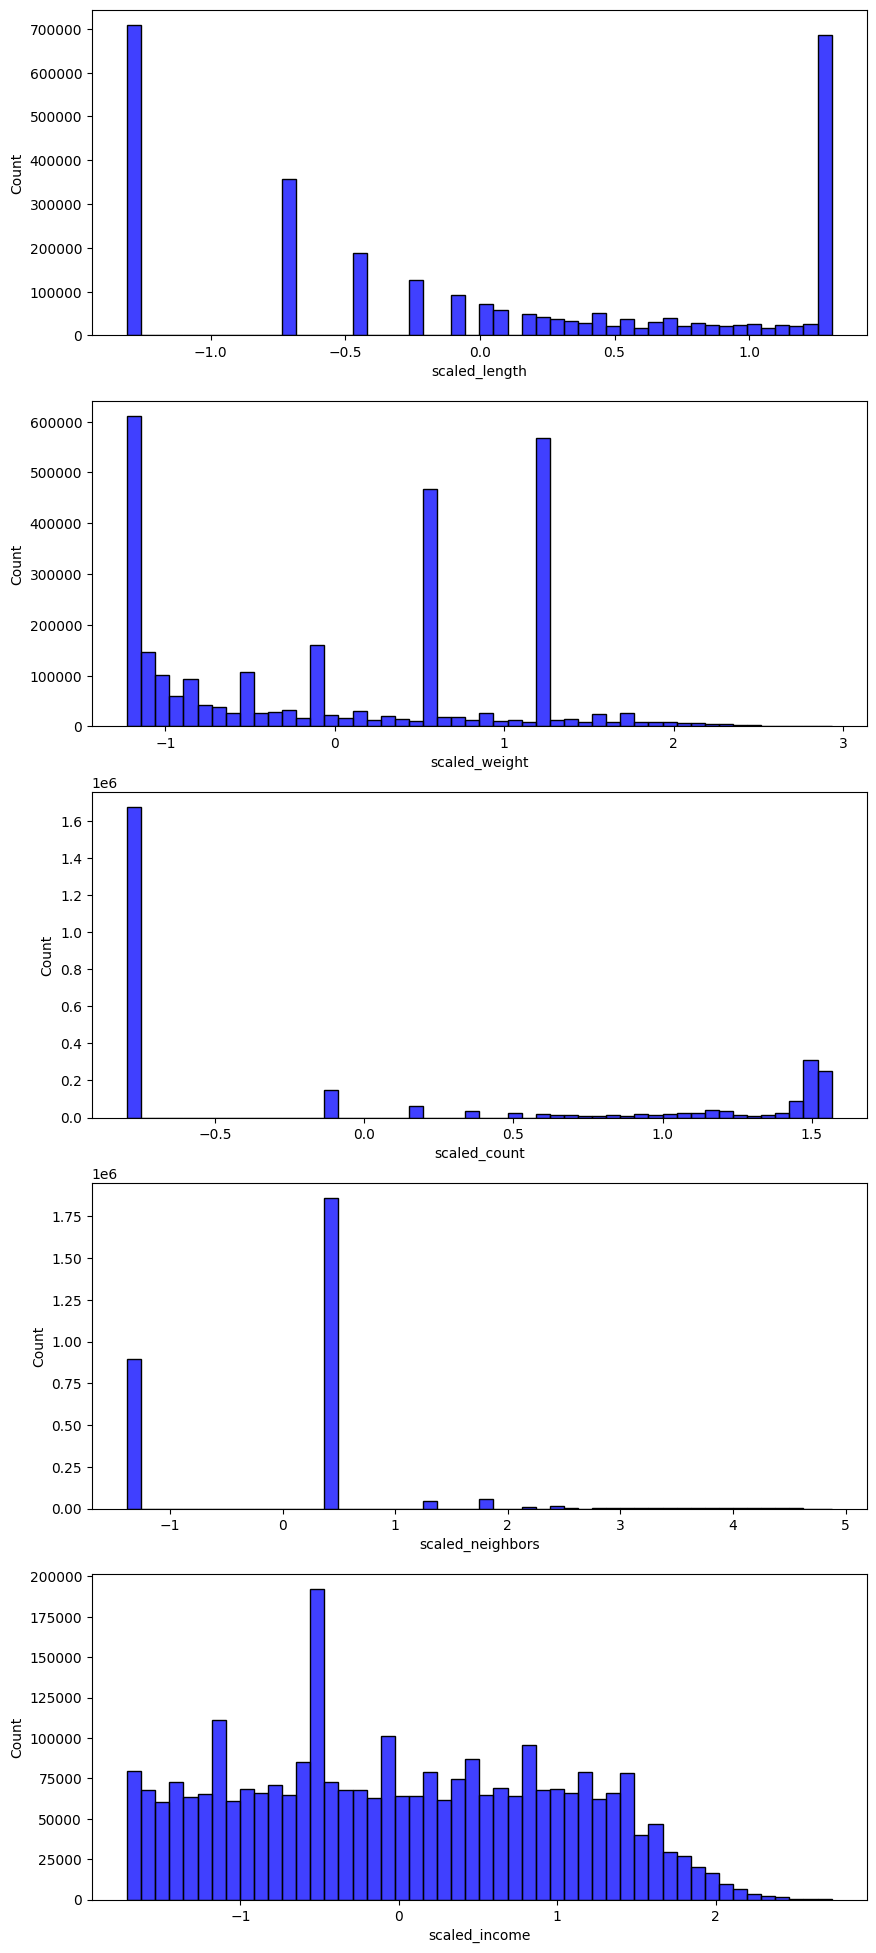

In [ ]:
fig, ax = plt.subplots(5, 1, figsize=(10, 10))
plt.subplots_adjust(top=2)

sns.histplot(df_scaled['scaled_length'], color='b', bins=50, ax=ax[0]);
sns.histplot(df_scaled['scaled_weight'], color='b', bins=50, ax=ax[1]);
sns.histplot(df_scaled['scaled_count'], color='b', bins=50, ax=ax[2]);
sns.histplot(df_scaled['scaled_neighbors'], color='b', bins=50, ax=ax[3]);
sns.histplot(df_scaled['scaled_income'], color='b', bins=50, ax=ax[4]);


Cyclical Features

Some features are inherently cyclical. Clear examples are time features, i.e., those features derived from datetime variables like the hours of the day, the days of the week, or the months of the year.

Days of the year and Days of the week are cyclical features.

Cyclical encoding

The trigonometric functions sine and cosine are periodic and repeat their values every 2 pi radians. Thus, to transform cyclical variables into (x, y) coordinates using these functions, first we need to normalize them to 2 pi radians.

We achieve this by dividing the variables’ values by their maximum value. Thus, the two new features are derived as follows:

    var_sin = sin(variable * (2. * pi / max_value))

    var_cos = cos(variable * (2. * pi / max_value))

In Python, we can encode cyclical features by using the Numpy functions sin and cos:
```python
import numpy as np

X[f"{variable}_sin"] = np.sin(X["variable"] * (2.0 * np.pi / X["variable"]).max())

X[f"{variable}_cos"] = np.cos(X["variable"] * (2.0 * np.pi / X["variable"]).max())
```
Reference:
https://feature-engine.trainindata.com/en/latest/user_guide/creation/CyclicalFeatures.html

In [ ]:
df['cyclical_day'] = np.sin(2.0 * np.pi * (df["day"] / df["day"].max()))

In [ ]:
df['cyclical_weekday'] = np.sin(2.0 * np.pi * (df["weekday"] / df["weekday"].max()))

Binarizer

class sklearn.preprocessing.Binarizer(*, threshold=0.0, copy=True)
[source]

    Binarize data (set feature values to 0 or 1) according to a threshold.

    Values greater than the threshold map to 1, while values less than or equal to the threshold map to 0. With the default threshold of 0, only positive values map to 1.

In [ ]:
binarizer = Binarizer().fit(df[['looped', 'length']])

In [ ]:
df['scaled_looped'] = binarizer.transform(df[['looped', 'length']])[:, 0]

# Mislabeled Data

Note that although we are certain about ransomware labels, we do not know if all white addresses are in fact not related to ransomware.

When compared to non-ransomware addresses, ransomware addresses exhibit more profound right skewness in distributions of feature values.

B. Label cleansing
In [1], the authors propose to first train filters on parts of
the training data in order to identify mislabeled examples in
the remaining training data. To this end, they use cross-fold
validation among decision trees, nearest neighbor classifiers
and linear machines. Mislabeled instances are subsequently
removed from the training set. Then, a learning algorithm is
trained on the reduced training set. They show empirically that
feeding a supervised algorithm with filtered instances results
in a higher predictive accuracy than without previous data
cleansing.

source: N. M. Müller and K. Markert, "Identifying Mislabeled Instances in Classification Datasets," 2019 International Joint Conference on Neural Networks (IJCNN), Budapest, Hungary, 2019, pp. 1-8, doi: 10.1109/IJCNN.2019.8851920. keywords: {Tools;Training;Labeling;Pipelines;Neural networks;Machine learning;Training data},



In [112]:
print('No Ransomware', round(df['ransomware'].value_counts()[0] / len(df) * 100, 2), '% of the dataset')
print('Ransomware', round(df['ransomware'].value_counts()[1] / len(df) * 100, 2), '% of the dataset')

No Ransomware 98.58 % of the dataset
Ransomware 1.42 % of the dataset


In [113]:
# New_df is from the random undersample data (fewer instances)
X = df.drop('ransomware', axis=1).copy()

In [114]:
# 1. Separate the data by their current labels
white_addresses = X[y == 0].copy()
ransomware_addresses = X[y == 1].copy()
ransomware_labels = y[y == 1]

## Isolation Forest

In [115]:
iso_filter = IsolationForest(contamination=0.02, random_state=42)

# 3. Fit and predict ONLY on the white addresses
# Returns 1 for normal, -1 for anomalous
white_addresses['is_anomaly'] = iso_filter.fit_predict(white_addresses)

# 4. Filter out the suspected hidden ransomware (-1)
# We only keep the rows where is_anomaly == 1
clean_white_addresses = white_addresses[white_addresses['is_anomaly'] == 1].drop(columns=['is_anomaly'])
clean_white_labels = y[clean_white_addresses.index]

# 5. Recombine the newly cleaned white addresses with the known ransomware
X_clean = pd.concat([clean_white_addresses, ransomware_addresses])
y_clean = pd.concat([clean_white_labels, ransomware_labels])

print(f"Original training size: {len(X)}")
print(f"Cleaned training size: {len(X_clean)}")
print(f"Removed {len(X) - len(X_clean)} suspicious 'white' addresses.")

Original training size: 2916697
Cleaned training size: 2859191
Removed 57506 suspicious 'white' addresses.


## Splitting the Data (Original DataFrame)

In [116]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.25, random_state=42,
                                                    stratify=y_clean)

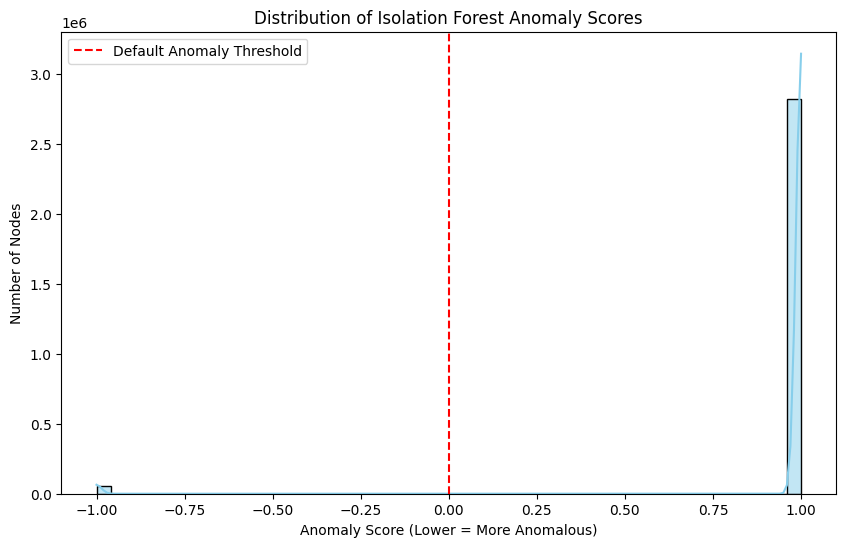

In [117]:
plt.figure(figsize=(10, 6))
# Plot the distribution of the scores
sns.histplot(white_addresses['is_anomaly'], bins=50, kde=True, color='skyblue')

# Add a vertical red line where the algorithm decided the cutoff was
# (Usually, predictions of -1 map to the lowest scores in the distribution)
plt.axvline(x=0, color='red', linestyle='--', label='Default Anomaly Threshold')

plt.title('Distribution of Isolation Forest Anomaly Scores')
plt.xlabel('Anomaly Score (Lower = More Anomalous)')
plt.ylabel('Number of Nodes')
plt.legend()
plt.show()

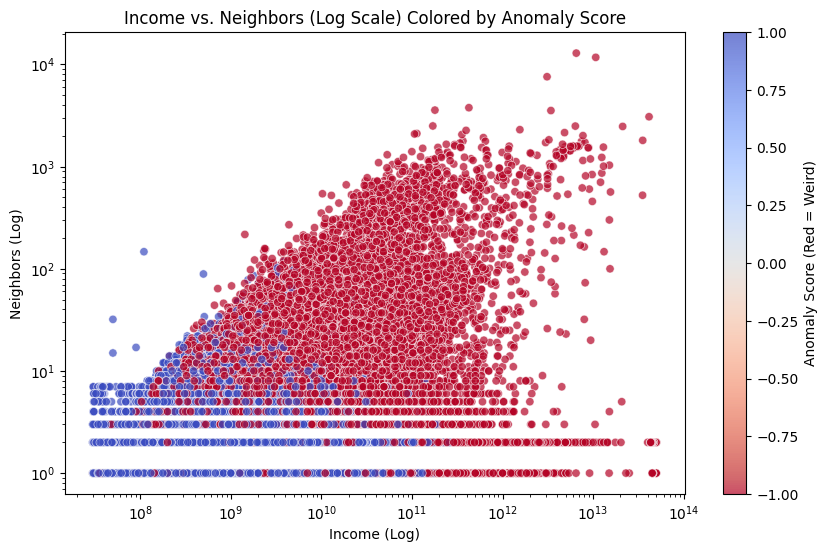

In [118]:
plt.figure(figsize=(10, 6))

# Plot Income vs Neighbors, colored by the anomaly score
# We use the 'coolwarm' colormap: Red = Low Score (Anomaly), Blue = High Score (Normal)
scatter = plt.scatter(
    white_addresses['income'],
    white_addresses['neighbors'],
    c=white_addresses['is_anomaly'],
    cmap='coolwarm_r',  # Reversed so red is anomalous
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)

plt.xscale('log')  # Essential for your massive numbers
plt.yscale('log')  # Essential for your massive numbers

plt.colorbar(scatter, label='Anomaly Score (Red = Weird)')
plt.title('Income vs. Neighbors (Log Scale) Colored by Anomaly Score')
plt.xlabel('Income (Log)')
plt.ylabel('Neighbors (Log)')
plt.show()

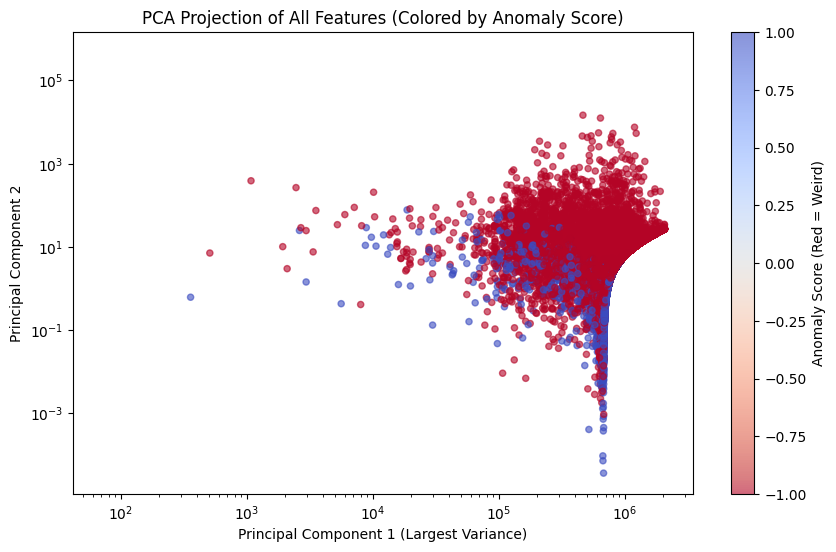

In [119]:
# 1. Scale the raw features (PCA is very sensitive to scale)
# We exclude the anomaly_score column from the PCA math
features_only = white_addresses.drop(columns=['is_anomaly'])
scaler = RobustScaler()
X_scaled_for_pca = scaler.fit_transform(features_only)

# 2. Crush the 8 dimensions down to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_for_pca)

# 3. Plot the result
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=white_addresses['is_anomaly'],
    cmap='coolwarm_r',
    alpha=0.6,
    s=20  # Dot size
)

plt.xscale('log')  # Essential for your massive numbers
plt.yscale('log')  # Essential for your massive numbers

plt.colorbar(scatter, label='Anomaly Score (Red = Weird)')
plt.title('PCA Projection of All Features (Colored by Anomaly Score)')
plt.xlabel('Principal Component 1 (Largest Variance)')
plt.ylabel('Principal Component 2')
plt.show()

## Cleanlab

In [120]:
# 1. Initialize your base classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Get out-of-sample predicted probabilities for the entire dataset
# This trains the model on folds of data and predicts on the hold-out fold
# so the model isn't "cheating" by having seen the data already.
print("Calculating probabilities (this may take a moment)...")
pred_probs = cross_val_predict(rf, X, y, method='predict_proba')

# 3. Let Cleanlab find the exact rows with label issues
# It returns a boolean array (True = mislabeled, False = correct label)
label_issues = find_label_issues(
    labels=y,
    pred_probs=pred_probs,
    return_indices_ranked_by=None
)

# 4. Filter the dataset!
# We use the tilde (~) to say "Keep rows that are NOT label issues"
X_cleanlab = X[~label_issues]
y_cleanlab = y[~label_issues]

print(f"Cleanlab identified {sum(label_issues)} likely mislabeled rows.")
print("These rows have been removed from X_clean and y_clean.")

Calculating probabilities (this may take a moment)...



KeyboardInterrupt



In [77]:
X_trainlab, X_testlab, y_trainlab, y_testlab = train_test_split(X_cleanlab, y_cleanlab, test_size=0.2, random_state=42,
                                                                stratify=y_cleanlab)

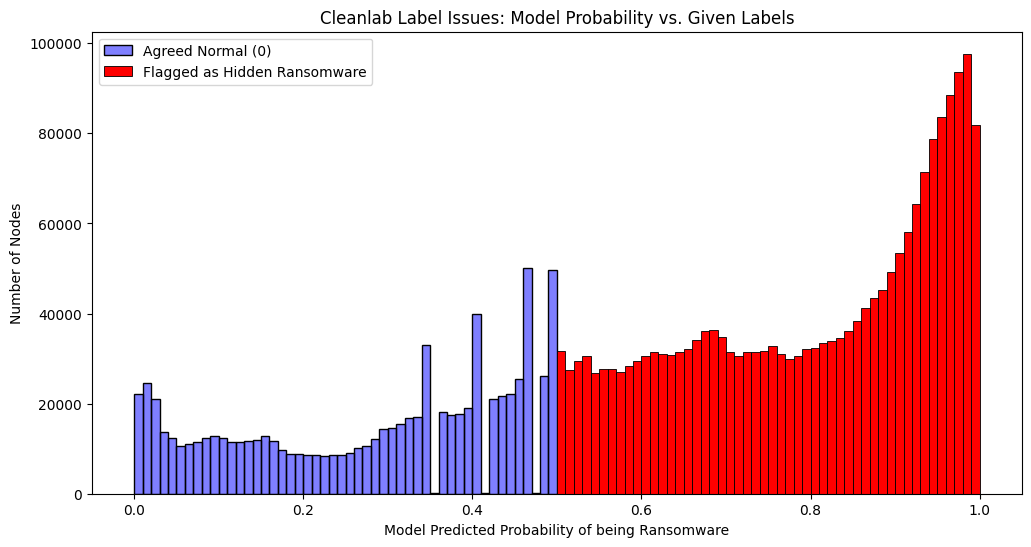

In [87]:
prob_ransomware = pred_probs[:, 1]

# 2. Create a temporary dataframe for plotting
plot_df = pd.DataFrame({
    'Given_Label': y,
    'Prob_Ransomware': prob_ransomware,
    'Is_Label_Issue': label_issues  # The boolean mask from Cleanlab
})

# 3. Plot the data
plt.figure(figsize=(12, 6))

# Plot the safe nodes that Cleanlab agreed were safe
sns.histplot(
    data=plot_df[(plot_df['Given_Label'] == 0) & (plot_df['Is_Label_Issue'] == False)],
    x='Prob_Ransomware', color='blue', label='Agreed Normal (0)', bins=50, alpha=0.5
)

# Plot the safe nodes that Cleanlab flagged as hidden ransomware!
sns.histplot(
    data=plot_df[(plot_df['Given_Label'] == 0) & (plot_df['Is_Label_Issue'] == True)],
    x='Prob_Ransomware', color='red', label='Flagged as Hidden Ransomware', bins=50, alpha=1.0
)

plt.title('Cleanlab Label Issues: Model Probability vs. Given Labels')
plt.xlabel('Model Predicted Probability of being Ransomware')
plt.ylabel('Number of Nodes')
plt.legend()
plt.show()

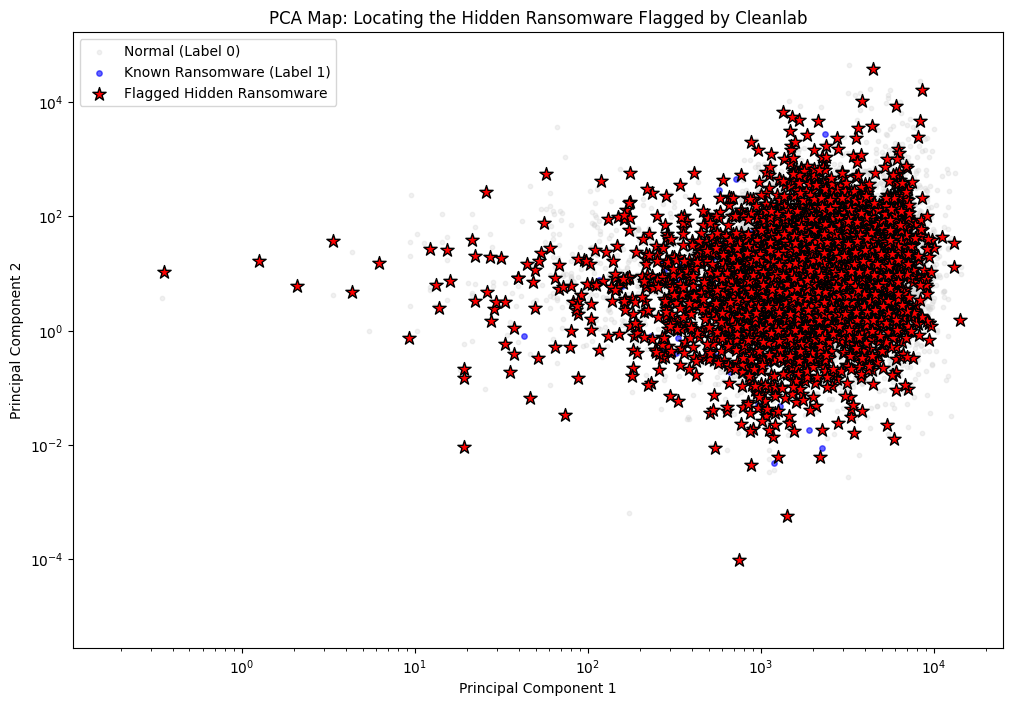

In [92]:
# 1. Scale features and apply PCA
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)  # Assuming X is your raw feature dataframe
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

# 2. Plot the normal nodes that Cleanlab kept (Gray)
normal_mask = (y == 0) & (~label_issues)
plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
            c='lightgray', label='Normal (Label 0)', alpha=0.3, s=10)

# 3. Plot the known ransomware nodes (Blue)
ransomware_mask = (y == 1)
plt.scatter(X_pca[ransomware_mask, 0], X_pca[ransomware_mask, 1],
            c='blue', label='Known Ransomware (Label 1)', alpha=0.6, s=15)

# 4. Plot the Cleanlab flagged issues (Red Stars)
flagged_mask = (y == 0) & (label_issues)
plt.scatter(X_pca[flagged_mask, 0], X_pca[flagged_mask, 1],
            c='red', label='Flagged Hidden Ransomware', marker='*', s=100, edgecolors='black')

plt.xscale('log')  # Essential for your massive numbers
plt.yscale('log')  # Essential for your massive numbers

plt.title('PCA Map: Locating the Hidden Ransomware Flagged by Cleanlab')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [103]:
# Create a copy of your features dataframe
compare_df = X.copy()

# Initialize a new column with a default value
compare_df['Transaction_Type'] = 'Normal Traffic'

# Label the Identified Ransomware (y == 1)
compare_df.loc[y == 1, 'Transaction_Type'] = 'Identified Ransomware'

# Label the Unidentified/Hidden Ransomware (y == 0 AND flagged by Cleanlab)
compare_df.loc[(y == 0) & (label_issues == True), 'Transaction_Type'] = 'Unidentified (Flagged)'

# Filter the dataframe to ONLY include these two groups
cohorts_df = compare_df[compare_df['Transaction_Type'].isin(['Identified Ransomware', 'Unidentified (Flagged)'])]

print(f"Comparing {sum(y == 1)} Identified nodes vs {sum((y == 0) & label_issues)} Unidentified nodes.")

Comparing 41413 Identified nodes vs 2087655 Unidentified nodes.


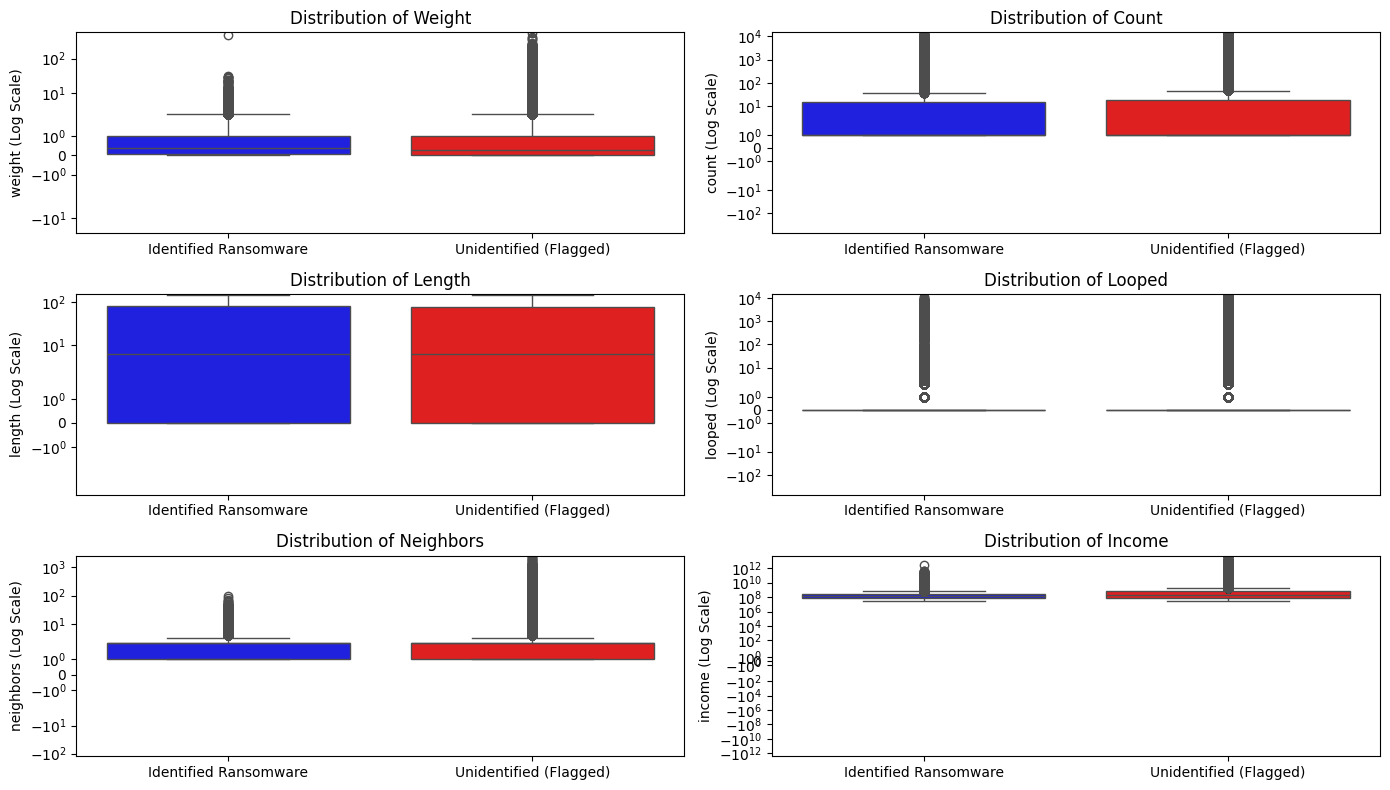

In [108]:
# Choose a few key features you want to compare
features_to_plot = [
    'weight',
    'count',
    'length',
    'looped',
    'neighbors',
    'income'
]

plt.figure(figsize=(14, 8))

# Loop through and create a subplot for each feature
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(3, 2, i)

    # Create the boxplot
    sns.boxplot(
        data=cohorts_df,
        x='Transaction_Type',
        y=feature,
        hue='Transaction_Type',
        palette=['blue', 'red']
    )

    # Apply Log10 scale safely (adding 1 to avoid log(0) errors)
    plt.yscale('symlog')
    plt.title(f'Distribution of {feature.capitalize()}')
    plt.ylabel(f'{feature} (Log Scale)')
    plt.xlabel('')

plt.tight_layout()
plt.show()

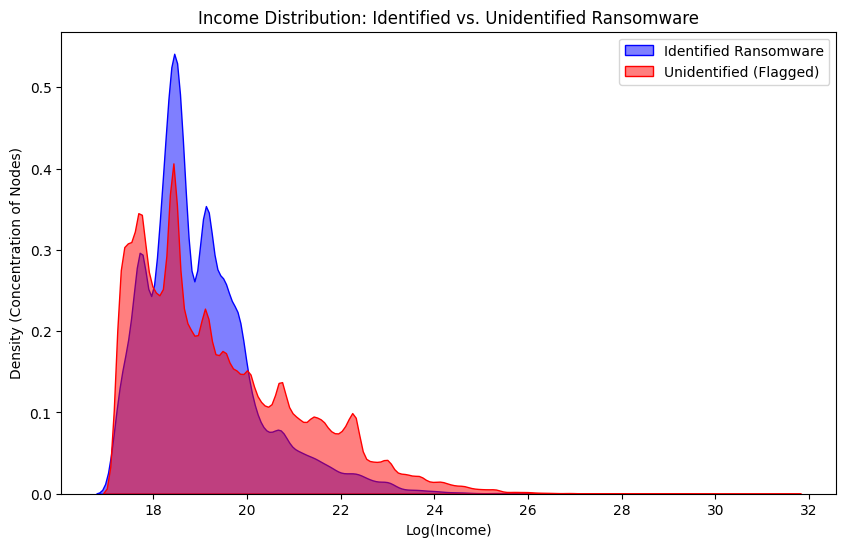

In [109]:
plt.figure(figsize=(10, 6))

# We apply a log transformation directly to the feature for smoother plotting
# np.log1p safely handles zeros
log_income_identified = np.log1p(cohorts_df[cohorts_df['Transaction_Type'] == 'Identified Ransomware']['income'])
log_income_unidentified = np.log1p(cohorts_df[cohorts_df['Transaction_Type'] == 'Unidentified (Flagged)']['income'])

# Plot Identified Ransomware
sns.kdeplot(log_income_identified, fill=True, color="blue", label="Identified Ransomware", alpha=0.5)

# Plot Unidentified (Flagged) Ransomware
sns.kdeplot(log_income_unidentified, fill=True, color="red", label="Unidentified (Flagged)", alpha=0.5)

plt.title('Income Distribution: Identified vs. Unidentified Ransomware')
plt.xlabel('Log(Income)')
plt.ylabel('Density (Concentration of Nodes)')
plt.legend()
plt.show()

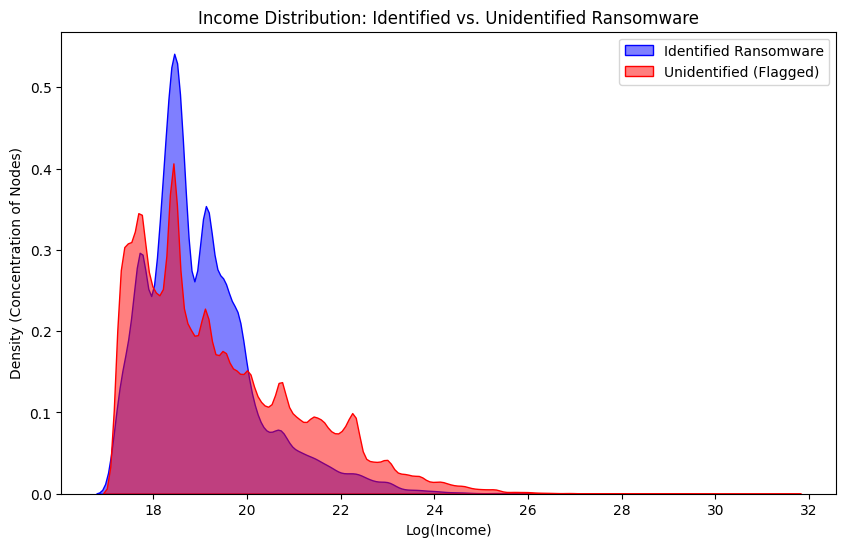

In [109]:
plt.figure(figsize=(10, 6))

# We apply a log transformation directly to the feature for smoother plotting
# np.log1p safely handles zeros
log_income_identified = np.log1p(cohorts_df[cohorts_df['Transaction_Type'] == 'Identified Ransomware']['income_per_length'])
log_income_unidentified = np.log1p(cohorts_df[cohorts_df['Transaction_Type'] == 'Unidentified (Flagged)']['income_per_length'])

# Plot Identified Ransomware
sns.kdeplot(log_income_identified, fill=True, color="blue", label="Identified Ransomware", alpha=0.5)

# Plot Unidentified (Flagged) Ransomware
sns.kdeplot(log_income_unidentified, fill=True, color="red", label="Unidentified (Flagged)", alpha=0.5)

plt.title('Income Distribution: Identified vs. Unidentified Ransomware')
plt.xlabel('Log(Income)')
plt.ylabel('Density (Concentration of Nodes)')
plt.legend()
plt.show()

# Splitting the Data (Original DataFrame), Random Under-Sampling

In [ ]:
sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print("Train:", train_index, "Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
print('-' * 100)

print('Label Distributions: \n')
print(train_counts_label / len(original_ytrain))
print(test_counts_label / len(original_ytest))

Train: [   8283    8284    8285 ... 2916694 2916695 2916696] Test: [     0      1      2 ... 616467 616468 616469]
Train: [      0       1       2 ... 2916694 2916695 2916696] Test: [   8283    8284    8285 ... 1191524 1191525 1191526]
Train: [      0       1       2 ... 2916694 2916695 2916696] Test: [  16566   16567   16568 ... 1766580 1766581 1766582]
Train: [      0       1       2 ... 2916694 2916695 2916696] Test: [  24849   24850   24851 ... 2341637 2341638 2341639]
Train: [      0       1       2 ... 2341637 2341638 2341639] Test: [  33131   33132   33133 ... 2916694 2916695 2916696]
----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.98580115 0.01419885]
[0.98580242 0.01419758]


## Balancing Ransomware Labels

In [ ]:
df_sample = df.sample(frac=0.02)

fraud_df = df_sample.loc[df['ransomware'] == 1]
non_fraud_df = df_sample.loc[df['ransomware'] == 0][:len(fraud_df)]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,year,day,length,weight,count,looped,neighbors,income,weekday,ransomware
2290678,2017,69,80,0.000267,24,0,1,4.000000e+07,4,0
16569,2014,135,144,0.389163,796,794,3,3.568900e+08,3,1
210702,2011,180,32,0.000523,30,0,2,5.000000e+07,2,0
2647101,2018,61,20,0.015625,1,0,2,7.644278e+08,4,0
170325,2011,139,34,0.000488,1,0,2,1.782244e+09,3,0


In [ ]:
print('Distribution of the ransomware in the subsample dataset')
print(new_df['ransomware'].value_counts() / len(new_df))
print(new_df.shape)

Distribution of the ransomware in the subsample dataset
ransomware
0    0.5
1    0.5
Name: count, dtype: float64
(1660, 10)


/tmp/ipykernel_34951/1743595312.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=new_df, x='ransomware', palette=sns.color_palette("tab10"))
/tmp/ipykernel_34951/1743595312.py:1: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(data=new_df, x='ransomware', palette=sns.color_palette("tab10"))


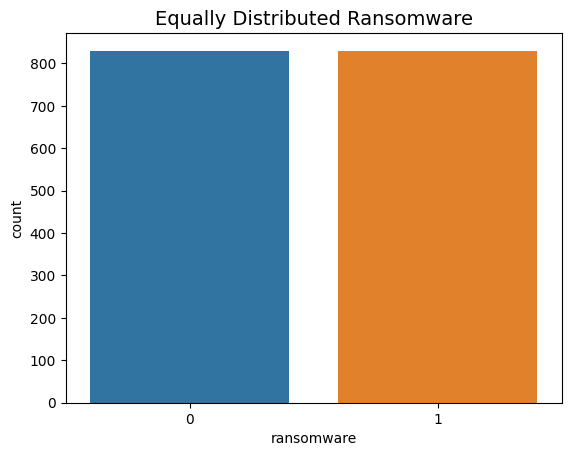

In [ ]:
sns.countplot(data=new_df, x='ransomware', palette=sns.color_palette("tab10"))
plt.title('Equally Distributed Ransomware', fontsize=14)
plt.show()


# Correlation Matrices

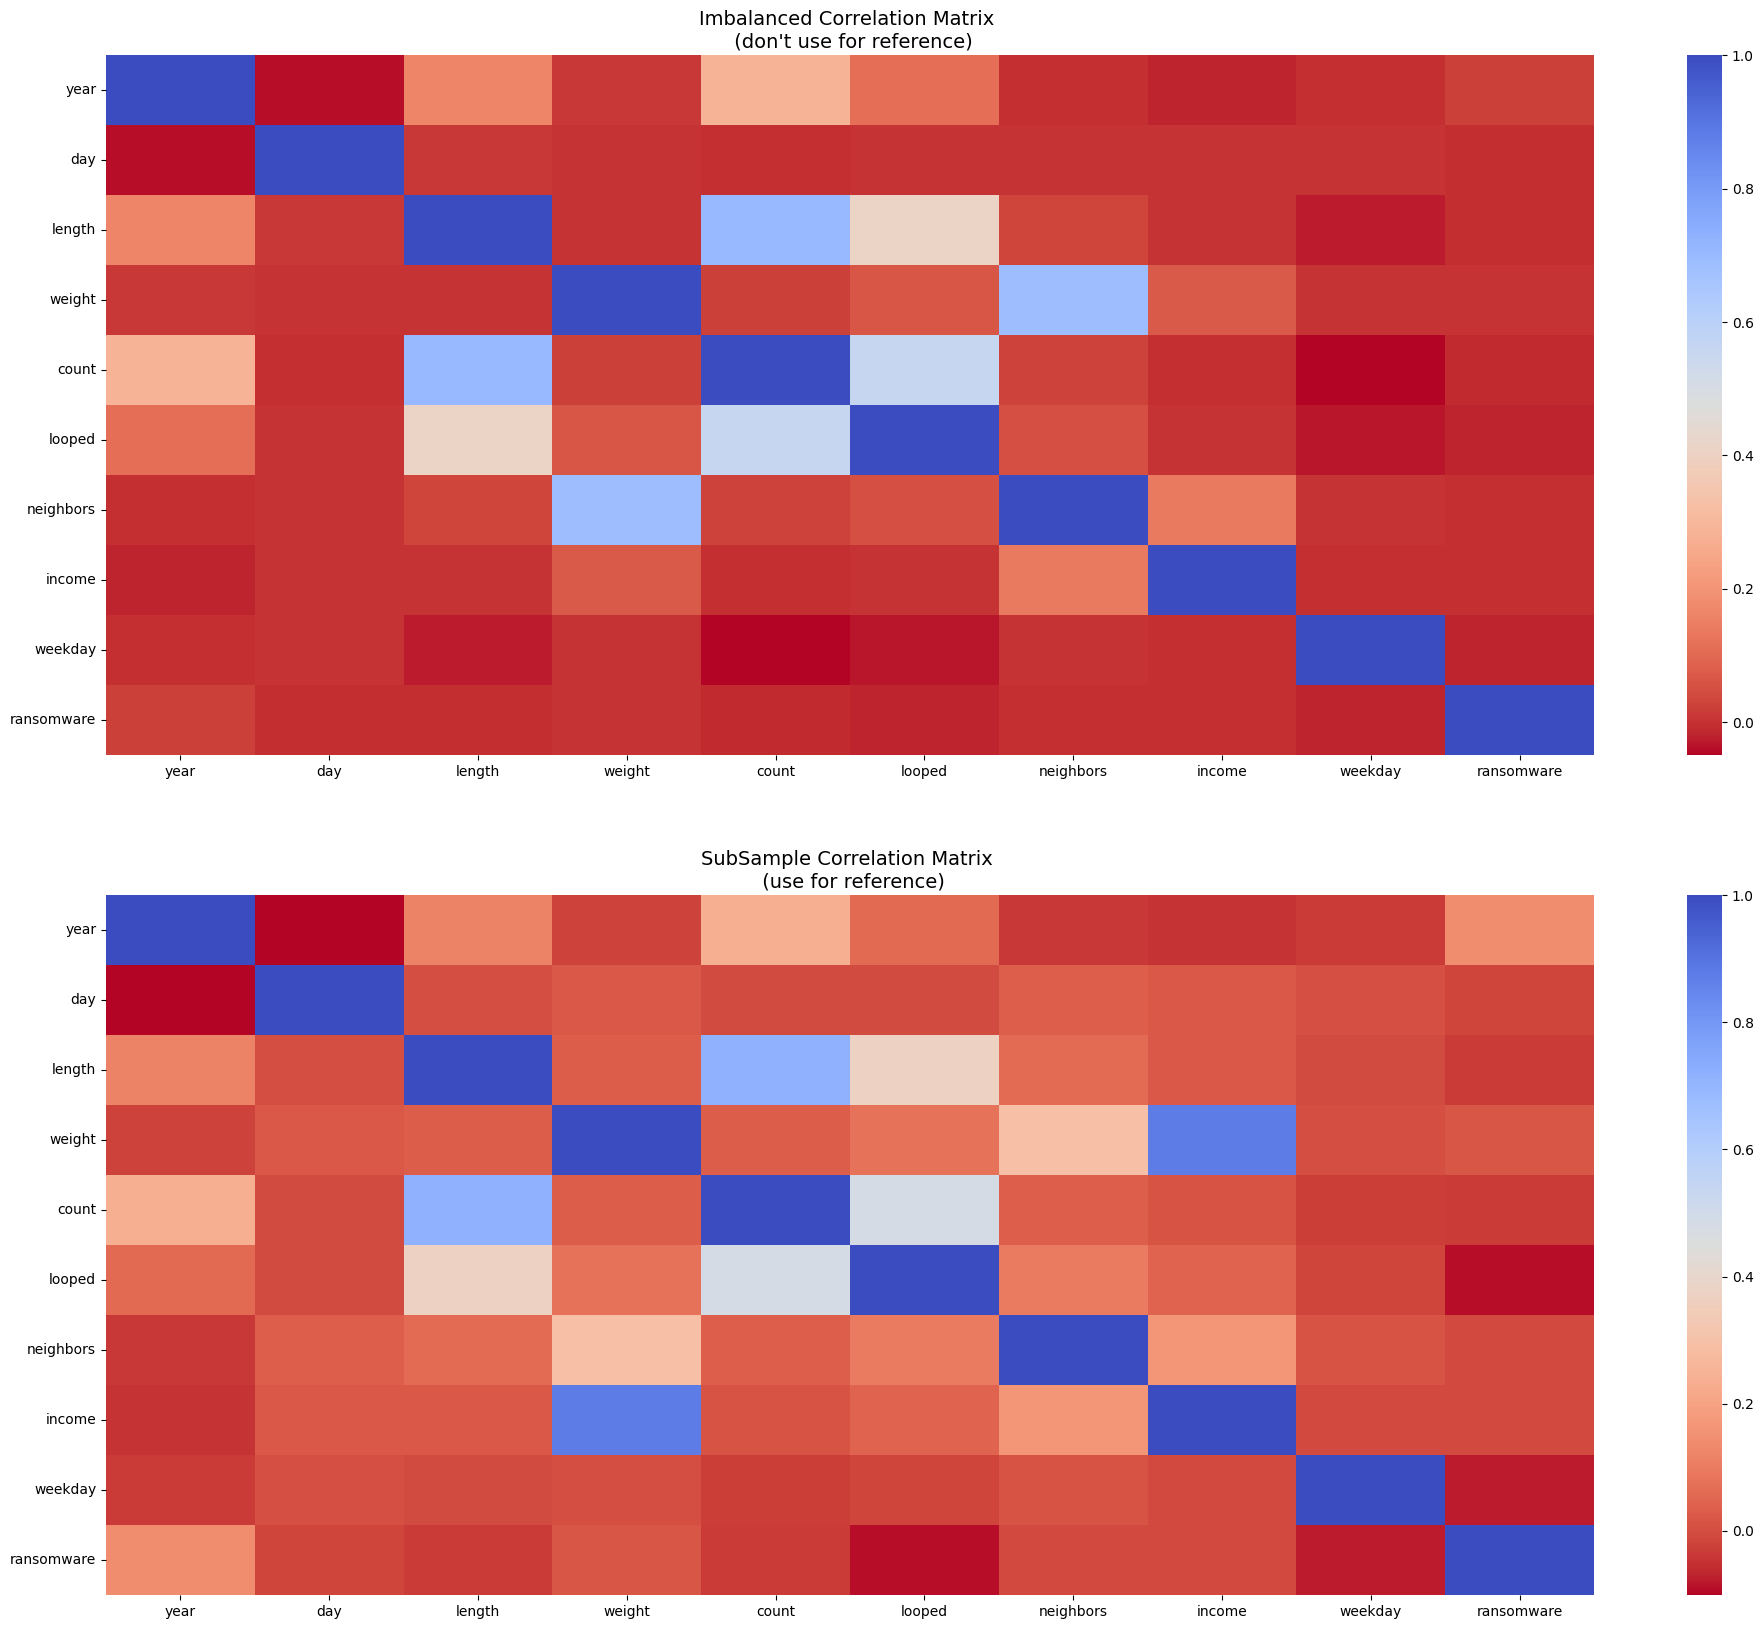

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 20))

# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size': 20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)

sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size': 20}, ax=ax2)
ax2.set_title('SubSample Correlation Matrix \n (use for reference)', fontsize=14)
plt.show()

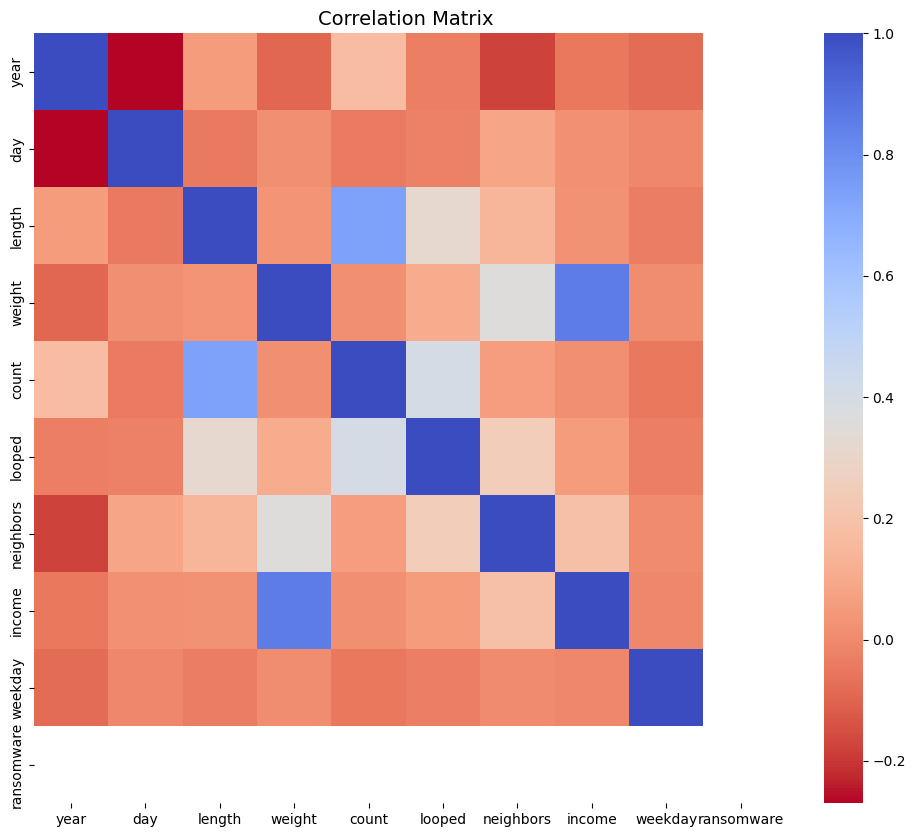

In [100]:
f, (ax1) = plt.subplots(1, 1, figsize=(12, 10))

# Entire DataFrame
corr = df[df['ransomware'] == 1].corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size': 10}, ax=ax1)
ax1.set_title("Correlation Matrix", fontsize=14)

plt.show()

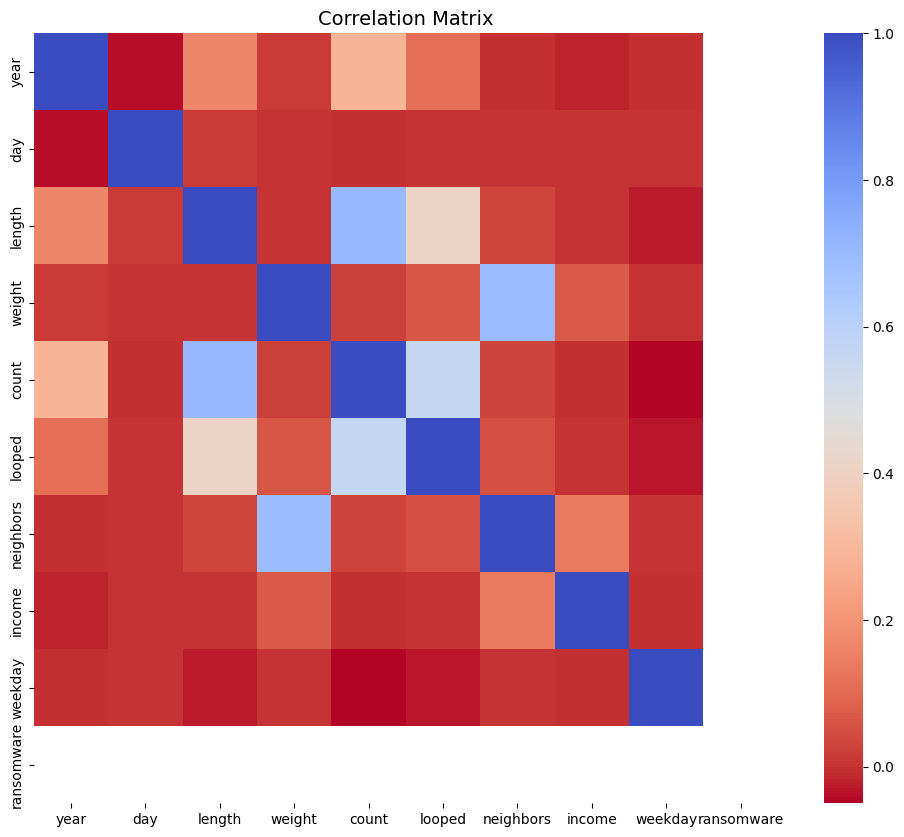

In [101]:
f, (ax1) = plt.subplots(1, 1, figsize=(12, 10))

# Entire DataFrame
corr = df[df['ransomware'] == 0].corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size': 10}, ax=ax1)
ax1.set_title("Correlation Matrix", fontsize=14)

plt.show()

In [ ]:
df.columns.to_list()

['year',
 'day',
 'length',
 'weight',
 'count',
 'looped',
 'neighbors',
 'income',
 'weekday',
 'ransomware']

/tmp/ipykernel_34951/2270056321.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ransomware", y=feature, data=new_df, palette=colors, ax=axes[index])
/tmp/ipykernel_34951/2270056321.py:6: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.boxplot(x="ransomware", y=feature, data=new_df, palette=colors, ax=axes[index])
/tmp/ipykernel_34951/2270056321.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ransomware", y=feature, data=new_df, palette=colors, ax=axes[index])
/tmp/ipykernel_34951/2270056321.py:6: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.boxplot(x="ransomware", y=fe

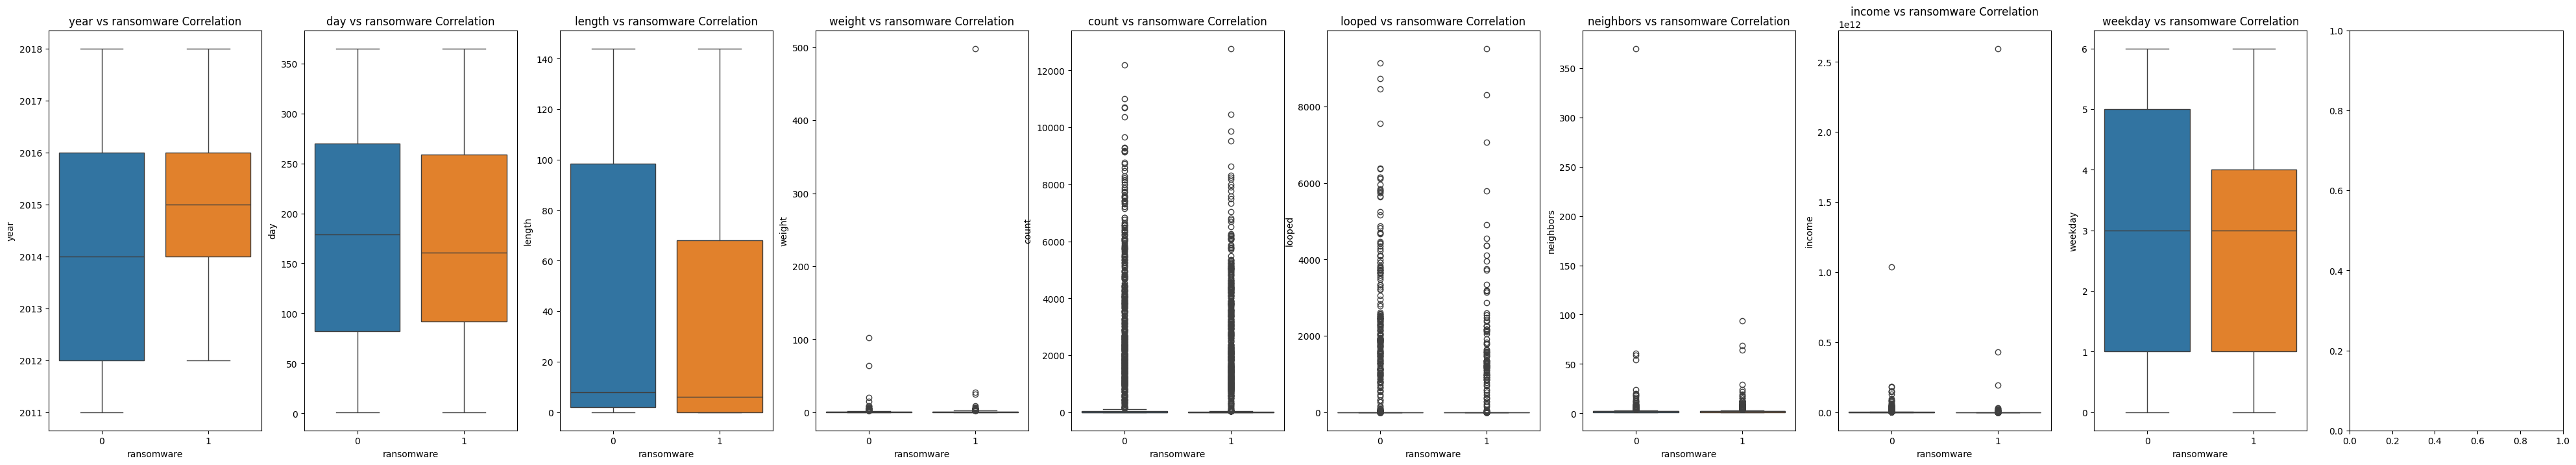

In [ ]:
f, axes = plt.subplots(ncols=len(df.columns.to_list()), figsize=(50, 8))
colors = sns.color_palette("tab10")

for index, feature in enumerate(new_df.columns.to_list()):
    if feature != "ransomware":
        sns.boxplot(x="ransomware", y=feature, data=new_df, palette=colors, ax=axes[index])
        axes[index].set_title(f"{feature} vs ransomware Correlation")

plt.show()



# Time Series Cross-validation

In [ ]:
tscv = TimeSeriesSplit(n_splits=10)

In [ ]:
for i, (train_index, test_index) in enumerate(tscv.split(df)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[     0      1      2 ... 265154 265155 265156]
  Test:  index=[265157 265158 265159 ... 530308 530309 530310]
Fold 1:
  Train: index=[     0      1      2 ... 530308 530309 530310]
  Test:  index=[530311 530312 530313 ... 795462 795463 795464]
Fold 2:
  Train: index=[     0      1      2 ... 795462 795463 795464]
  Test:  index=[ 795465  795466  795467 ... 1060616 1060617 1060618]
Fold 3:
  Train: index=[      0       1       2 ... 1060616 1060617 1060618]
  Test:  index=[1060619 1060620 1060621 ... 1325770 1325771 1325772]
Fold 4:
  Train: index=[      0       1       2 ... 1325770 1325771 1325772]
  Test:  index=[1325773 1325774 1325775 ... 1590924 1590925 1590926]
Fold 5:
  Train: index=[      0       1       2 ... 1590924 1590925 1590926]
  Test:  index=[1590927 1590928 1590929 ... 1856078 1856079 1856080]
Fold 6:
  Train: index=[      0       1       2 ... 1856078 1856079 1856080]
  Test:  index=[1856081 1856082 1856083 ... 2121232 2121233 2121234]
Fold 7:


# Dimensionality Reduction and Clustering

In [ ]:
# New_df is from the random undersample data (fewer instances)
X = new_df.drop('ransomware', axis=1).copy()
y = new_df['ransomware']

In [ ]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)

In [ ]:
# T-SNE Implementation
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(white_addresses.values)

# PCA Implementation
X_reduced_pca = PCA(n_components=2, random_state=69420).fit_transform(white_addresses.values)

# TruncatedSVD
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=69420).fit_transform(
    white_addresses.values)

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)

blue_patch = mpl.patches.Patch(color='#0A0AFF', label='No Ransom')
red_patch = mpl.patches.Patch(color='#AF0000', label='Ransom')

# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=(y == 0), cmap='coolwarm', label='No Ransom', linewidths=2)
ax1.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=(y == 1), cmap='coolwarm', label='Ransom', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])

# PCA scatter plot
ax2.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=(y == 0), cmap='coolwarm', label='No Ransom', linewidths=2)
ax2.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=(y == 1), cmap='coolwarm', label='Ransom', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:, 0], X_reduced_svd[:, 1], c=(y == 0), cmap='coolwarm', label='No Ransom', linewidths=2)
ax3.scatter(X_reduced_svd[:, 0], X_reduced_svd[:, 1], c=(y == 1), cmap='coolwarm', label='Ransom', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

# Isolation Forest

In [ ]:
features = X_clean.columns.to_list()
features

In [52]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
iso_forest.fit(X_clean)

X_clean['anomaly_score'] = iso_forest.decision_function(X_clean[features])

In [ ]:
X_clean['anomaly_score']

# Random Forest

In [63]:
rus = RandomUnderSampler(random_state=42)

# 2. Fit and transform ONLY the training data
X_train_balanced, y_train_balanced = X_trainlab[:2000], y_trainlab[:2000]

print(f"Original training shape: {X_train.shape}")
print(f"Balanced training shape: {X_train_balanced.shape}")
print(f"Ransomware count: {sum(y_train_balanced == 1)}, Normal count: {sum(y_train_balanced == 0)}")

Original training shape: (128826, 9)
Balanced training shape: (28060, 9)
Ransomware count: 14030, Normal count: 14030


In [68]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

rf_model.fit(X_train_balanced, y_train_balanced)

# Make predictions on the unseen test data
y_pred = rf_model.predict(X_test)

print("\n--- Random Forest Model Evaluation ---")
print(classification_report(y_test, y_pred))


--- Random Forest Model Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     31507
           1       0.02      0.03      0.03       700

    accuracy                           0.95     32207
   macro avg       0.50      0.50      0.50     32207
weighted avg       0.96      0.95      0.96     32207



In [73]:
skf = StratifiedKFold(n_splits=10, random_state=None, shuffle=False)

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

for train_index, test_index in skf.split(X_clean, y_clean):
    print("Train:", train_index, "Test:", test_index)
    x_train_fold, x_test_fold = X_clean.iloc[train_index], X_clean.iloc[test_index]
    y_train_fold, y_test_fold = y_clean.iloc[train_index], y_clean.iloc[test_index]

    rf_model.fit(x_train_fold, y_train_fold)

    # Make predictions on the unseen test data
    y_pred = rf_model.predict(x_test_fold)

    print("\n--- Random Forest Model Evaluation ---")
    print(classification_report(y_test_fold, y_pred))

Train: [ 281778  281779  281780 ... 2859188 2859189 2859190] Test: [      0       1       2 ... 2821917 2821918 2821919]

--- Random Forest Model Evaluation ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    281778
           1       0.97      0.25      0.40      4142

    accuracy                           0.99    285920
   macro avg       0.98      0.63      0.70    285920
weighted avg       0.99      0.99      0.99    285920

Train: [      0       1       2 ... 2859188 2859189 2859190] Test: [ 281778  281779  281780 ... 2826058 2826059 2826060]

--- Random Forest Model Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.58      0.73    281778
           1       0.01      0.27      0.02      4141

    accuracy                           0.57    285919
   macro avg       0.50      0.42      0.37    285919
weighted avg       0.97      0.57      0.72    285919

Train: [      0       1 

KeyboardInterrupt: 

# XGBoost

In [80]:
# Calculate the imbalance ratio from the full training set
# Formula: (Count of Normal Class 0) / (Count of Ransomware Class 1)
normal_count = sum(y_train == 0)
ransomware_count = sum(y_train == 1)
scale_weight = normal_count / ransomware_count

print(f"Applying scale_pos_weight of: {scale_weight:.2f}")

# create model instance
xgbst = XGBClassifier(scale_pos_weight=scale_weight, n_estimators=100, max_depth=10, learning_rate=0.1,
                      eval_metric='logloss')
# fit model
xgbst.fit(X_train, y_train)
# make predictions
y_pred = xgbst.predict(X_test)

print("\n--- XGBoost Evaluation ---")
print(classification_report(y_test, y_pred))

Applying scale_pos_weight of: 68.04

--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    563556
           1       0.10      0.89      0.18      8283

    accuracy                           0.89    571839
   macro avg       0.55      0.89      0.56    571839
weighted avg       0.99      0.89      0.93    571839



In [81]:
# Calculate the imbalance ratio from the full training set
# Formula: (Count of Normal Class 0) / (Count of Ransomware Class 1)
normal_count = sum(y_trainlab == 0)
ransomware_count = sum(y_trainlab == 1)
scale_weight = normal_count / ransomware_count

print(f"Applying scale_pos_weight of: {scale_weight:.2f}")

# create model instance
xgbst = XGBClassifier(scale_pos_weight=scale_weight, n_estimators=100, max_depth=10, learning_rate=0.1,
                      eval_metric='logloss')
# fit model
xgbst.fit(X_trainlab, y_trainlab)
# make predictions
y_pred = xgbst.predict(X_testlab)

print("\n--- XGBoost Evaluation ---")
print(classification_report(y_testlab, y_pred))

Applying scale_pos_weight of: 44.91

--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    157526
           1       0.99      0.99      0.99      3508

    accuracy                           1.00    161034
   macro avg       0.99      1.00      1.00    161034
weighted avg       1.00      1.00      1.00    161034



In [ ]:
# 2. Set up the plot size
fig, ax = plt.subplots(figsize=(12, 8))

# 3. Plot the feature importances using the 'gain' metric
xgbst.plot_importance(
    xgbst,
    importance_type='gain',       # Focuses on the quality of the split, not just frequency
    max_num_features=15,          # Show the top 15 features
    height=0.6,                   # Thickness of the bars
    ax=ax,
    color='coral',
    title='XGBoost Feature Importance (Information Gain)',
    xlabel='Average Gain per Split'
)

# 4. Clean up the aesthetics
plt.grid(False, axis='y') # Remove horizontal grid lines for cleaner look
plt.tight_layout()
plt.show()

# 5. Optional: Print the exact numerical scores in a table
importance_dict = xgbst.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Gain_Score': list(importance_dict.values())
}).sort_values(by='Gain_Score', ascending=False)

print("\nTop 5 Features by Gain:")
print(importance_df.head(5).to_string(index=False))